# Processing of chromatin accessibility modality using pycisTopic

For this tutorial, we are processing the medulloblastoma mouse model single cell multiome data from:

_Shiraishi, R. & Cancila, G. et al. (2024). Cancer-specific epigenome identifies oncogenic hijacking by nuclear factor I family proteins for medulloblastoma progression. Dev. Cell , 59:2302-2319._

This data set contains three samples comprising FACS sorted cells. These cells reflect the progression from healthy precursors to tumor cells:

1. Ptch1GNP: granule neuron precursors, P7
2. PNC: preneoplastic cells, P28
3. Tumor: tumor cells, adult mice

Data was downloaded from the Gene Expression Omnibus:

https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE240362

The `GSE240362_RAW.tar` file contains the raw gene expression counts files in HDF5 format (.h5) and ATAC fragment files. This is the typical output you would obtain from the [10X Genomics Cellranger software](https://www.10xgenomics.com/support/software/cell-ranger/latest/getting-started/cr-what-is-cell-ranger).

The fragment files are processed with _pycisTopic_.

For additional information on processing single cell ATAC data with pycisTopic, see:
* https://pycistopic.readthedocs.io/en/latest/notebooks/human_cerebellum.html

## Data re-formatting

Fragments were sorted  prior to running pycisTopic using the following command-line instructions:

```
for f in *_fragments.tsv.gz
do
        ofile=${f%.tsv.gz}_sorted.tsv
        echo "*** $f --> $ofile ***"
        echo "Sorting..."
        zcat $f | grep -v "#" |  sort -k1,1 -k2,2n -k3,3n > $ofile
        echo "Compressing..."
        pigz -p 8 $ofile
        echo "Done."
done
```

pycisTopic needs indexed files. For this purpose, files were recompressed with `bgzip`and indexes were added to the files with `tabix`:

```
for f in *_fragments_sorted.tsv.gz;
do
        echo "Uncompressing '$f' ..."
        gzip -d $f
        echo "bgzipping '$f'..."
        bgzip ${f%.gz}
        echo "Computing index ..."
        tabix -p bed $f;
        echo "Done."
done
```

## Consensus peaks

Consensus peaks are inferred from the fragment files of the three samples. For _pycisTopic_, you usually identify characeristics peaks per cell type or cluster. We will use the clusters that we identified in the gene expression modality in this notebook.

In [1]:
import os
outdir = '/storage/nhecker/embl/GSE240362/pycistopic_mm10'

os.makedirs(outdir, exist_ok = True)

Samples are assigned to the fragment files.

In [2]:
# Input files
import os

samples = ['Ptch1GNP', 'PNC', 'Tumor']


path_fragments = ['/storage/nhecker/embl/GSE240362/GSM7791839_032103_fragments_sorted.tsv.gz',
                  '/storage/nhecker/embl/GSE240362/GSM7791841_RS03056_fragments_sorted.tsv.gz',
                  '/storage/nhecker/embl/GSE240362/GSM7791843_RS03060_fragments_sorted.tsv.gz'
                 ]

os.makedirs(outdir, exist_ok=True)

We load the cell metadata from our RNA anndata object.

In [3]:
import scanpy as sc

path_rna = '/storage/nhecker/embl/GSE240362/scanpy/rna_medulloblastoma.h5ad'

adata_rna = sc.read(path_rna)
cell_data = adata_rna.obs.copy()
cell_data

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


,sample,doublet_score,predicted_doublet,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,n_genes,leiden_0.1,leiden_0.25,leiden_0.5,leiden_0.75,leiden_1.0,leiden_1.5,leiden_2.0,leiden_2.5,leiden_3.0
AAACAGCCAAAGGTAC-1__Ptch1GNP,Ptch1GNP,0.112527,False,2327,7.752765,4287.0,8.363576,19.594122,25.705622,34.219734,...,2327,2,2,3,3,3,1,5,8,10
AAACAGCCAATGCCCG-1__Ptch1GNP,Ptch1GNP,0.010193,False,1624,7.393263,3181.0,8.065266,24.740648,32.977051,43.791261,...,1624,2,2,4,5,6,7,10,13,14
AAACAGCCACCTCACC-1__Ptch1GNP,Ptch1GNP,0.017131,False,3436,8.142354,8641.0,9.064389,21.444277,28.457354,37.044324,...,3436,4,5,7,8,11,16,18,22,25
AAACAGCCACGAACAG-1__Ptch1GNP,Ptch1GNP,0.202797,False,4443,8.399310,11592.0,9.358157,19.142512,25.258799,32.962388,...,4443,2,3,5,6,8,11,13,15,18
AAACAGCCATAATCAC-1__Ptch1GNP,Ptch1GNP,0.051130,False,1868,7.533159,3699.0,8.216088,25.574480,32.197891,41.605839,...,1868,2,2,3,3,3,1,8,8,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTAACCTAG-1__Tumor,Tumor,0.040000,False,1025,6.933423,1979.0,7.590852,33.956544,42.546741,53.764528,...,1025,1,1,0,0,10,13,11,9,12
TTTGTTGGTACTGATG-1__Tumor,Tumor,0.166870,False,1415,7.255591,2690.0,7.897668,31.040892,38.066914,47.546468,...,1415,1,1,0,0,4,5,9,7,3
TTTGTTGGTATTCGTC-1__Tumor,Tumor,0.074952,False,407,6.011267,1080.0,6.985642,65.925926,71.574074,80.833333,...,407,1,1,0,0,1,0,12,11,8
TTTGTTGGTATTGTGG-1__Tumor,Tumor,0.066121,False,843,6.738152,1492.0,7.308543,34.182306,43.230563,56.635389,...,843,1,1,0,0,4,0,9,9,3


_pycisTopic_ needs the chromosome sizes in the peak detection process. Since the fragment files were generated using the mouse mm10 genome, we are downloading the mm10 chromosome sizes file here.

In [4]:
import pandas as pd

chromsizes = pd.read_table(
    "http://hgdownload.cse.ucsc.edu/goldenPath/mm10/bigZips/mm10.chrom.sizes",
    header = None,
    names = ["Chromosome", "End"]
)
chromsizes.insert(1, "Start", 0)
chromsizes.head()

,Chromosome,Start,End
0,chr1,0,195471971
1,chr2,0,182113224
2,chrX,0,171031299
3,chr3,0,160039680
4,chr4,0,156508116


Before detecting consensus peaks, fragments are aggregated into pseudo-bulk profiles based on the clusters identified in the gene expression modality, here we use the clusters at resolution 0.5 (`leiden_0.5`).

In [5]:
fragments_dict = {
    'Ptch1GNP': '/storage/nhecker/embl/GSE240362/GSM7791839_032103_fragments_sorted.tsv.gz',
    'PNC': '/storage/nhecker/embl/GSE240362/GSM7791841_RS03056_fragments_sorted.tsv.gz',
    'Tumor': '/storage/nhecker/embl/GSE240362/GSM7791843_RS03060_fragments_sorted.tsv.gz'    
}

In [6]:
from pycisTopic.pseudobulk_peak_calling import export_pseudobulk
os.makedirs(os.path.join(outdir, "consensus_peak_calling"), exist_ok = True)
os.makedirs(os.path.join(outdir, "consensus_peak_calling/pseudobulk_bed_files"), exist_ok = True)
os.makedirs(os.path.join(outdir, "consensus_peak_calling/pseudobulk_bw_files"), exist_ok = True)


bw_paths, bed_paths = export_pseudobulk(
    input_data = cell_data,
    variable = "leiden_0.5",
    sample_id_col = "sample",
    chromsizes = chromsizes,
    bed_path = os.path.join(outdir, "consensus_peak_calling/pseudobulk_bed_files"),
    bigwig_path = os.path.join(outdir, "consensus_peak_calling/pseudobulk_bw_files"),
    path_to_fragments = fragments_dict,
    n_cpu = 10,
    normalize_bigwig = True,
    temp_dir = "/storage/nhecker/temp",
    split_pattern = "__"
)

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-16 20:52:29,119	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


2026-02-16 20:52:29,215 cisTopic     INFO     Splitting fragments by cell type.
2026-02-16 20:53:56,970 cisTopic     INFO     generating bigwig files


/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources

In [7]:
with open(os.path.join(outdir, "consensus_peak_calling/bw_paths.tsv"), "wt") as f:
    for v in bw_paths:
        _ = f.write(f"{v}\t{bw_paths[v]}\n")

In [8]:
with open(os.path.join(outdir, "consensus_peak_calling/bed_paths.tsv"), "wt") as f:
    for v in bed_paths:
        _ = f.write(f"{v}\t{bed_paths[v]}\n")

In [9]:
bw_paths = {}
with open(os.path.join(outdir, "consensus_peak_calling/bw_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bw_paths.update({v: p})

In [10]:
bed_paths = {}
with open(os.path.join(outdir, "consensus_peak_calling/bed_paths.tsv")) as f:
    for line in f:
        v, p = line.strip().split("\t")
        bed_paths.update({v: p})

The pseudobulk profiles are used for peak calling. We are using _MACS2_ as a peak caller here.

In [11]:
from pycisTopic.pseudobulk_peak_calling import peak_calling
macs_path = "/home/nikolai/.conda/envs/scenicplus/bin/macs2"

os.makedirs(os.path.join(outdir, "consensus_peak_calling/MACS"), exist_ok = True)

narrow_peak_dict = peak_calling(
    macs_path = macs_path,
    bed_paths = bed_paths,
    outdir = os.path.join(os.path.join(outdir, "consensus_peak_calling/MACS")),
    genome_size = 'hs',
    n_cpu = 10,
    input_format = 'BEDPE',
    shift = 73,
    ext_size = 146,
    keep_dup = 'all',
    q_value = 0.05,
    _temp_dir = '/storage/nhecker/temp/ray_spill'
)

2026-02-16 20:55:47,525	INFO worker.py:1724 -- Started a local Ray instance.
(pid=4044701) /home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
(pid=4044701)   from pkg_resources import DistributionNotFound, get_distribution


(macs_call_peak_ray pid=4044702) 2026-02-16 20:55:48,628 cisTopic     INFO     Calling peaks for 0 with /home/nikolai/.conda/envs/scenicplus/bin/macs2 callpeak --treatment /storage/nhecker/embl/GSE240362/pycistopic_mm10/consensus_peak_calling/pseudobulk_bed_files/0.fragments.tsv.gz --name 0  --outdir /storage/nhecker/embl/GSE240362/pycistopic_mm10/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 --nomodel --shift 73 --extsize 146 --keep-dup all --call-summits --nolambda
(macs_call_peak_ray pid=4044706) 2026-02-16 20:56:01,876 cisTopic     INFO     8 done!
(macs_call_peak_ray pid=4044707) 2026-02-16 20:55:48,659 cisTopic     INFO     Calling peaks for 7 with /home/nikolai/.conda/envs/scenicplus/bin/macs2 callpeak --treatment /storage/nhecker/embl/GSE240362/pycistopic_mm10/consensus_peak_calling/pseudobulk_bed_files/7.fragments.tsv.gz --name 7  --outdir /storage/nhecker/embl/GSE240362/pycistopic_mm10/consensus_peak_calling/MACS --format BEDPE --gsize hs --qvalue 0.05 -

(pid=4044704) /home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81. [repeated 9x across cluster]
(pid=4044704)   from pkg_resources import DistributionNotFound, get_distribution [repeated 9x across cluster]


From the called peaks per `leiden_0.5` cluster, we are inferring the consensus peaks across clusters.

In [12]:
from pycisTopic.iterative_peak_calling import get_consensus_peaks
# Other param
peak_half_width=250
path_to_blacklist="/storage/nhecker/blacklist/mm10-blacklist.v2.bed"


# Get consensus peaks
consensus_peaks = get_consensus_peaks(
    narrow_peaks_dict = narrow_peak_dict,
    peak_half_width = peak_half_width,
    chromsizes = chromsizes,
    path_to_blacklist = path_to_blacklist)

2026-02-16 20:59:07,076 cisTopic     INFO     Extending and merging peaks per class
2026-02-16 20:59:56,569 cisTopic     INFO     Normalizing peak scores
2026-02-16 20:59:56,956 cisTopic     INFO     Merging peaks
Warning! Start and End columns now have different dtypes: int64 and int32
2026-02-16 21:00:38,584 cisTopic     INFO     Done!


In [13]:
consensus_peaks.to_bed(
    path = os.path.join(outdir, "consensus_peak_calling/consensus_regions.bed"),
    keep =True,
    compression = 'infer',
    chain = False)

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.get(noncanonical)], axis=1)
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pyranges/out.py:37: FutureWarning: Passing a set as an indexer is deprecated and will raise in a future version. Use a list instead.
  return pd.concat([outdf, df.

In [14]:
os.path.join(outdir, "consensus_peak_calling/consensus_regions.bed")

'/storage/nhecker/embl/GSE240362/pycistopic_mm10/consensus_peak_calling/consensus_regions.bed'

# QC

Quality controls is performed using following metrics:
* the number of unique fragments per cell
* the enrichment of peaks near transcription start sites (TSS)
* the fraction of fragments in peaks (FRIP)

In [15]:
import os


outdir = "/storage/nhecker/embl/GSE240362/pycistopic_mm10"
qcdir = outdir + "/qc"

os.makedirs(qcdir, exist_ok=True)

For computing the TSS enrichment, we have to download the correct gene annotation file. In this case, we are using an older mouse genome (mm10). Therefore, we have to specify a URL to an ENSEMBL archive version of the gene annotation (`http://aug2020.archive.ensembl.org/`) that was made for the mm10 genome.

In [32]:
! /home/nikolai/.conda/envs/scenicplus/bin/pycistopic tss get_tss \
    --output /storage/nhecker/embl/GSE240362/pycistopic_mm10/qc/tss.bed \
    --server http://aug2020.archive.ensembl.org/ \
    --name "mmusculus_gene_ensembl" \
    --to-chrom-source ucsc \
    --ucsc mm10

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
- Get TSS annotation from Ensembl BioMart with the following settings:
  - biomart_name: "mmusculus_gene_ensembl"
  - biomart_host: "http://aug2020.archive.ensembl.org/"
  - transcript_type: ['protein_coding']
  - use_cache: True
- Getting chromosome sizes and alias mapping for "mm10" from UCSC.
- Update chromosome names in TSS annotation to "ucsc" chromosome names.
- Writing TSS annotation BED file to "/storage/nhecker/embl/GSE240362/pycistopic_mm10/qc/tss.bed".


In [33]:
qcdir

'/storage/nhecker/embl/GSE240362/pycistopic_mm10/qc'

In [34]:
!head /storage/nhecker/embl/GSE240362/pycistopic_mm10/qc/tss.bed | column -t

#     Chromosome  Start  End      Gene  Score  Strand          Transcript_type
chrM  14144       14145  mt-Cytb  .     +      protein_coding  
chrM  14069       14070  mt-Nd6   .     -      protein_coding  
chrM  11741       11742  mt-Nd5   .     +      protein_coding  
chrM  10166       10167  mt-Nd4   .     +      protein_coding  
chrM  9876        9877   mt-Nd4l  .     +      protein_coding  
chrM  9458        9459   mt-Nd3   .     +      protein_coding  
chrM  8606        8607   mt-Co3   .     +      protein_coding  
chrM  7926        7927   mt-Atp6  .     +      protein_coding  
chrM  7765        7766   mt-Atp8  .     +      protein_coding  


After creating the TSS file, we can run _pycisTopic_'s QC script. This a command-line script that we run per sample. We are creating the commands with the proper parameters per sample. If you installed _pycisTopic_ in a conda environment you may have to specify the path to the pycisTopic command-line interface in your conda environment. In my case it is:
`/home/nikolai/.conda/envs/scenicplus/bin/pycistopic qc`

In [35]:
fragments_dict = {
    'Ptch1GNP': '/storage/nhecker/embl/GSE240362/GSM7791839_032103_fragments_sorted.tsv.gz',
    'PNC': '/storage/nhecker/embl/GSE240362/GSM7791841_RS03056_fragments_sorted.tsv.gz',
    'Tumor': '/storage/nhecker/embl/GSE240362/GSM7791843_RS03060_fragments_sorted.tsv.gz'    
}

In [36]:
import os

indir = "/storage/nhecker/embl/GSE240362/pycistopic_mm10"

regions_bed_filename = os.path.join(indir, "consensus_peak_calling/consensus_regions.bed")
tss_bed_filename = os.path.join(indir, "qc", "tss.bed")

pycistopic_qc_commands_filename = os.path.join(qcdir, "pycistopic_qc_commands.txt")

# Create text file with all pycistopic qc command lines.
with open(pycistopic_qc_commands_filename, "w") as fh:
    for sample, fragment_filename in fragments_dict.items():
        print(
            "/home/nikolai/.conda/envs/scenicplus/bin/pycistopic qc",
            f"--fragments {fragment_filename}",
            f"--regions {regions_bed_filename}",
            f"--tss {tss_bed_filename}",
            f"--output {qcdir}/{sample}",
            sep=" ",
            file=fh,
        )

In [37]:
pycistopic_qc_commands_filename

'/storage/nhecker/embl/GSE240362/pycistopic_mm10/qc/pycistopic_qc_commands.txt'

To run the commands in parallel, we pipe the commands into the command line tool `parallel`:

In [38]:
! cat /storage/nhecker/embl/GSE240362/pycistopic_mm10/qc/pycistopic_qc_commands.txt | parallel -j 3 {}

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources

After running the QC script, we can load the data from the QC directory `qcdir` and plot the QC metrics. First, we plot sample summary statistics.

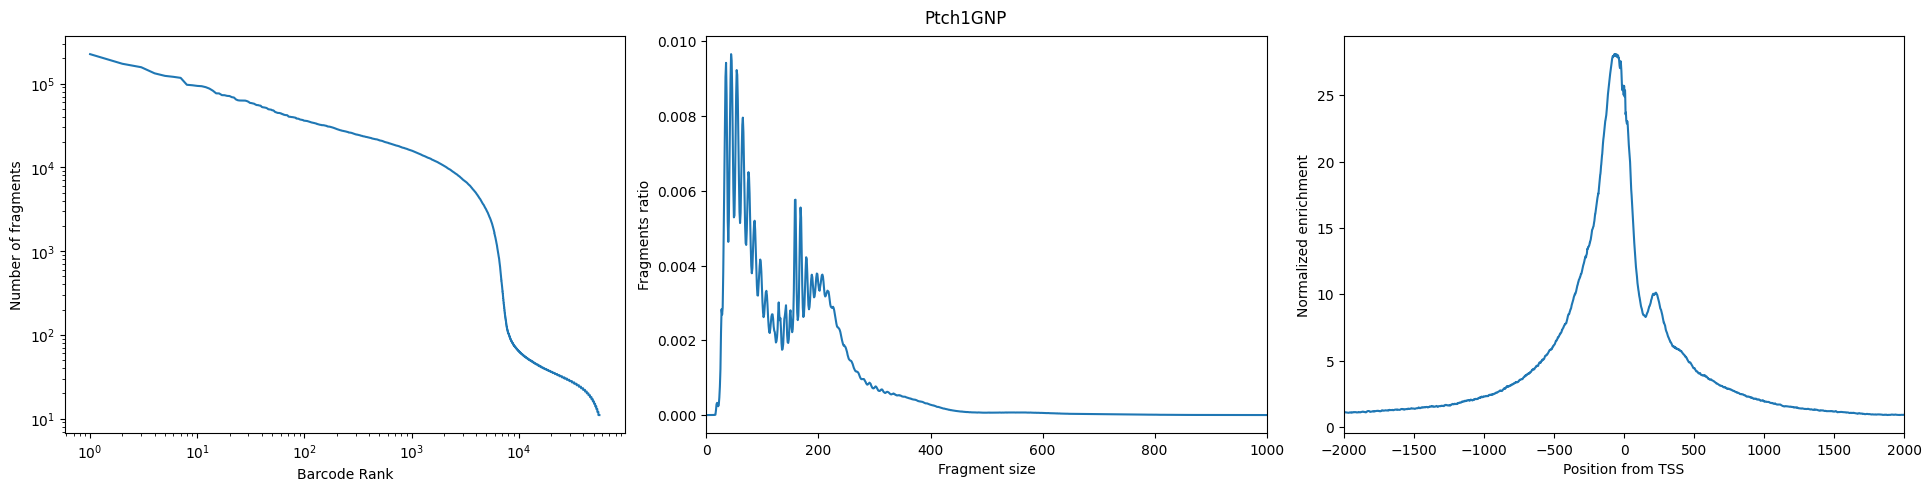

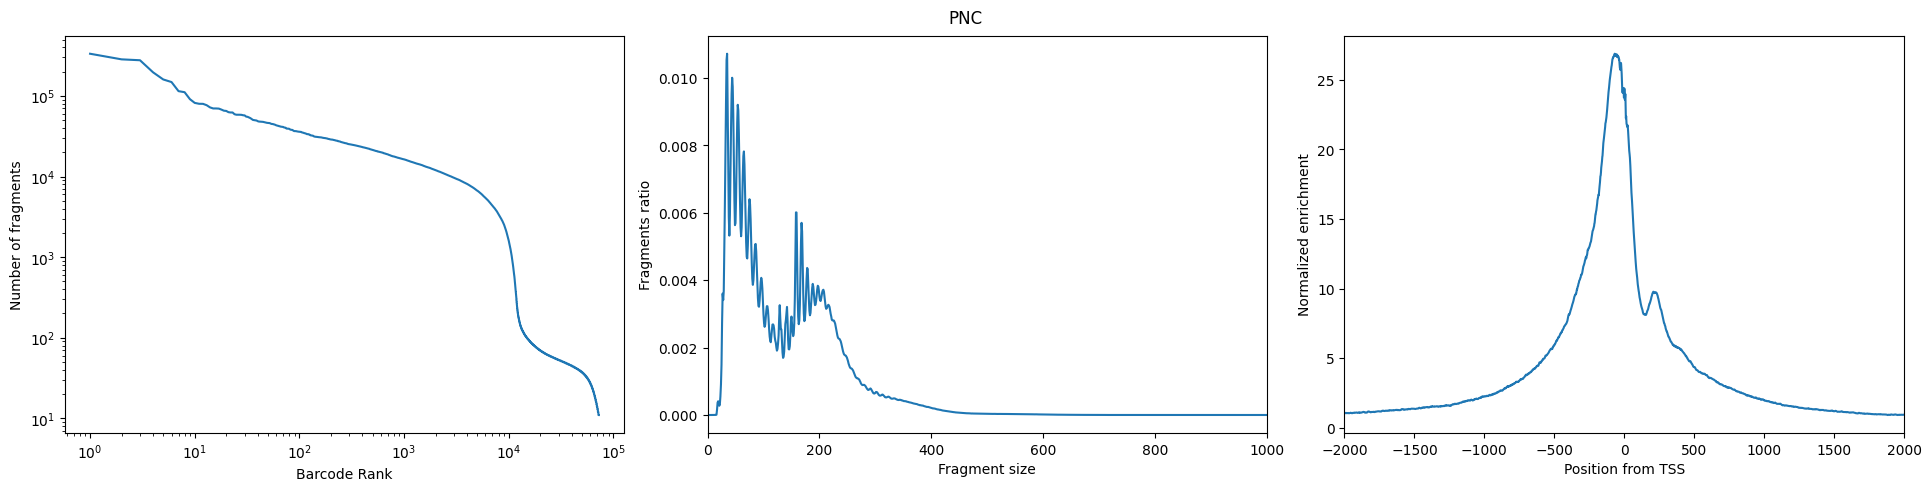

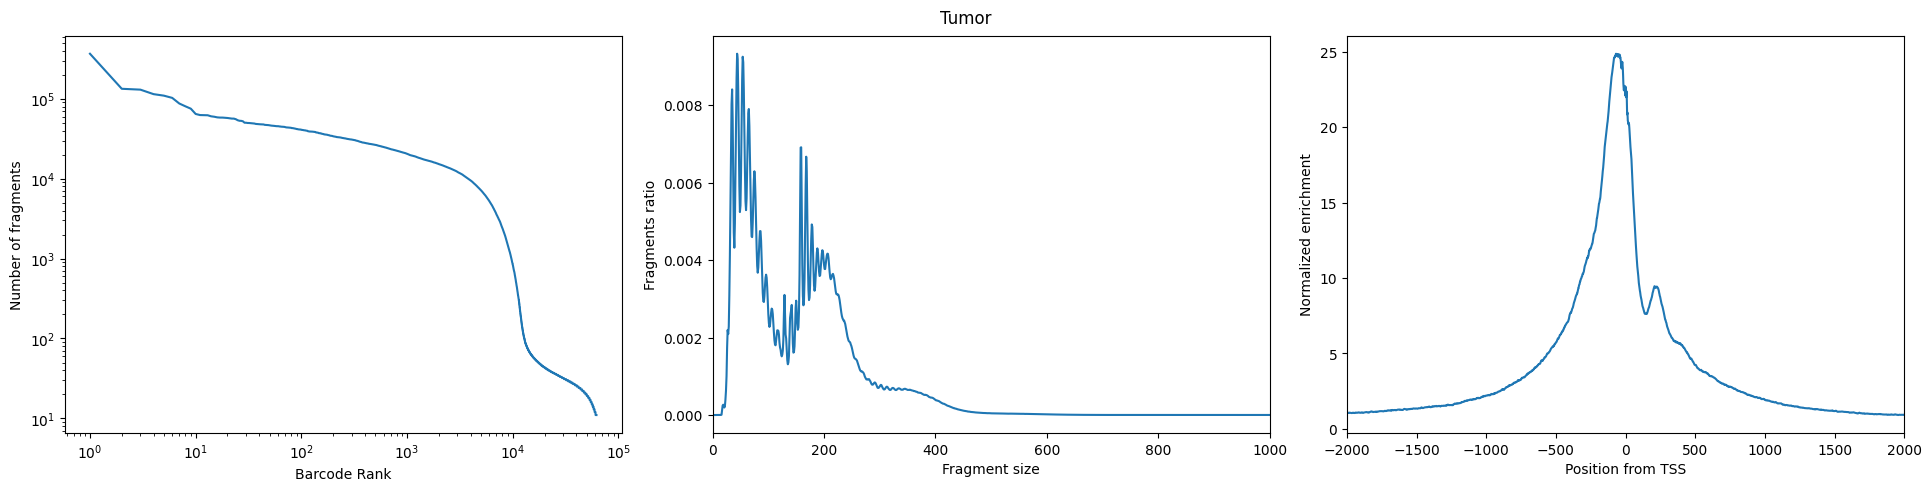

In [39]:
from pycisTopic.plotting.qc_plot import plot_sample_stats, plot_barcode_stats
import matplotlib.pyplot as plt

for sample_id in fragments_dict:
    fig = plot_sample_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = qcdir
    )

Second, we plot metrics per cell and filter cell barcodes based on these metrics. There is an automated thresholding option in _pycTopic_, which often works well. It is still recommended to visually inspect the plots and adjust threshold accordingly.

In [40]:
from pycisTopic.qc import get_barcodes_passing_qc_for_sample
sample_id_to_barcodes_passing_filters = {}
sample_id_to_thresholds = {}
for sample_id in fragments_dict:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir = qcdir,
            unique_fragments_threshold = None, # use automatic thresholding
            tss_enrichment_threshold = None, # use automatic thresholding
            frip_threshold = 0,
            use_automatic_thresholds = True,
    )

Ptch1GNP:
	Using automatic threshold for unique fragments: 1990.3144773650454
	Using automatic threshold for TSS enrichment: 16.4036443812208
PNC:
	Using automatic threshold for unique fragments: 1711.7574844257276
	Using automatic threshold for TSS enrichment: 14.76012216323046
Tumor:
	Using automatic threshold for unique fragments: 1762.5026004108604
	Using automatic threshold for TSS enrichment: 14.451314356435645


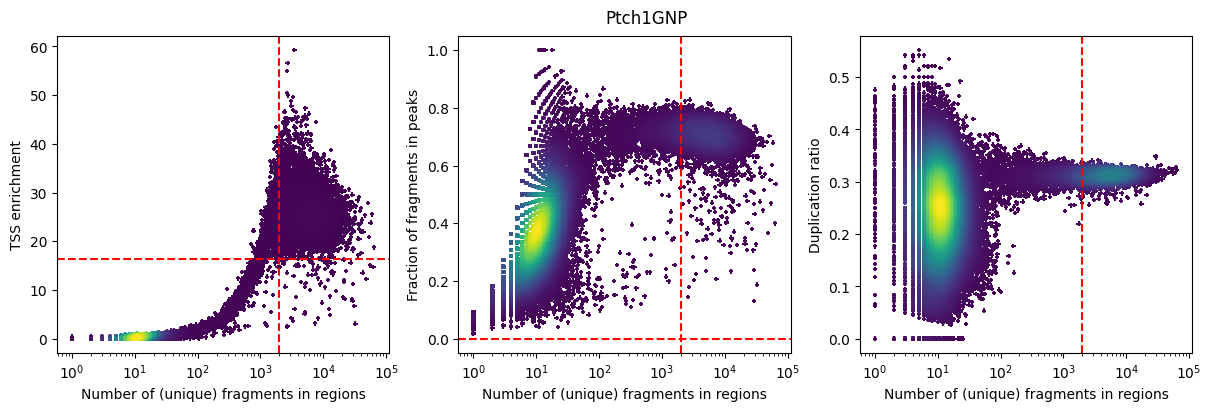

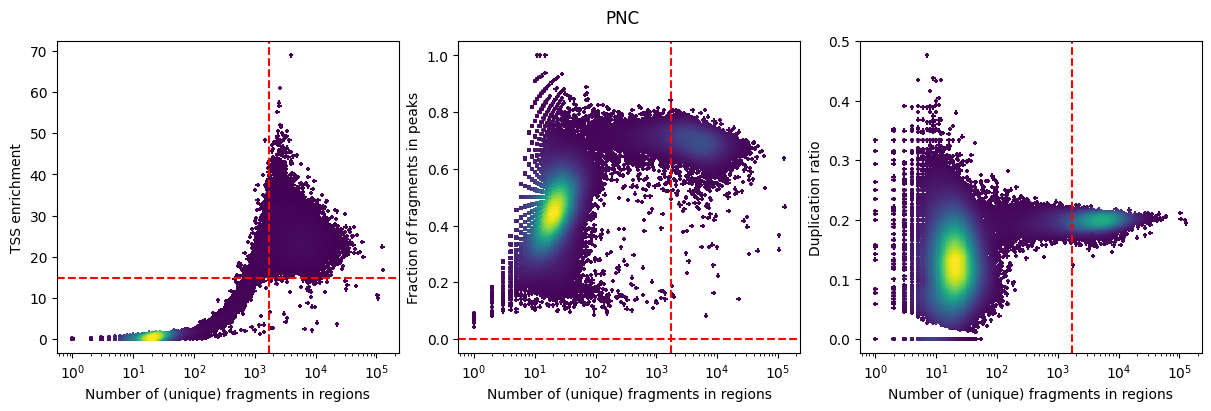

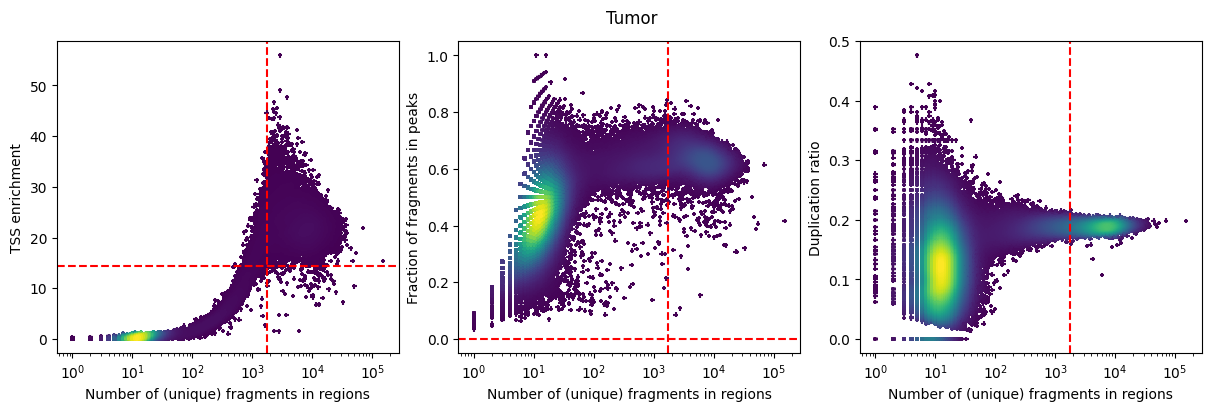

In [41]:
for sample_id in fragments_dict:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = qcdir,
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,
        **sample_id_to_thresholds[sample_id]
    )

We are slightly adjusting the thresholds to filter the cell barcodes.

In [53]:
for sample_id in fragments_dict:
    (
        sample_id_to_barcodes_passing_filters[sample_id],
        sample_id_to_thresholds[sample_id]
    ) = get_barcodes_passing_qc_for_sample(
            sample_id = sample_id,
            pycistopic_qc_output_dir = qcdir,
            unique_fragments_threshold = 1000, 
            tss_enrichment_threshold = 12, 
            frip_threshold = 0,
            use_automatic_thresholds = False,
    )

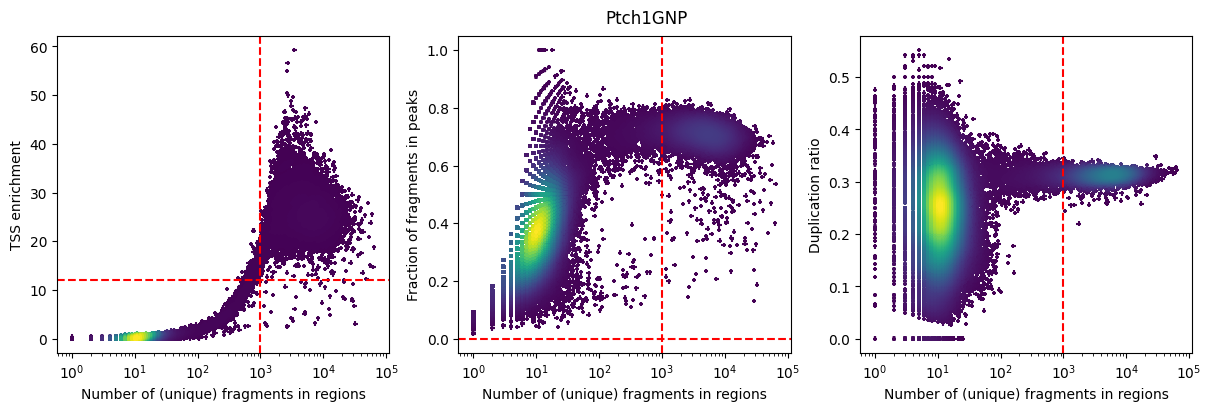

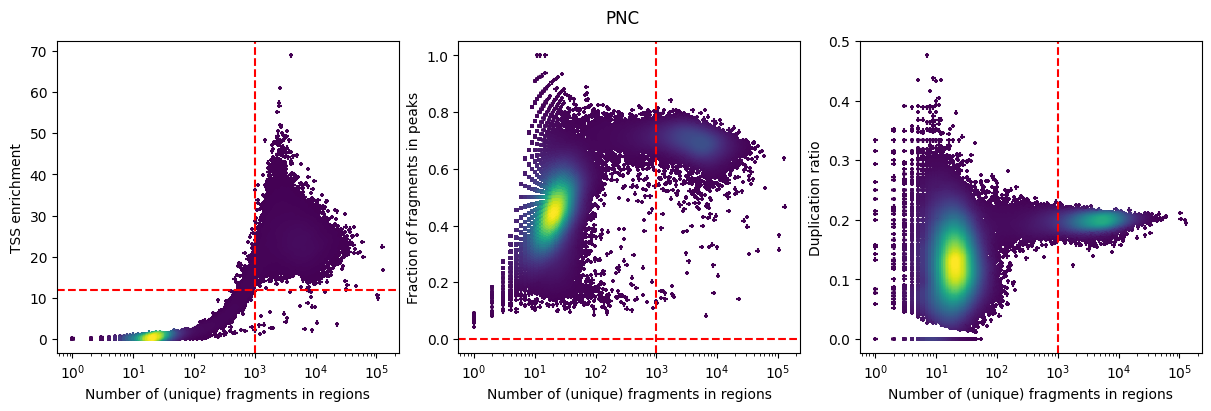

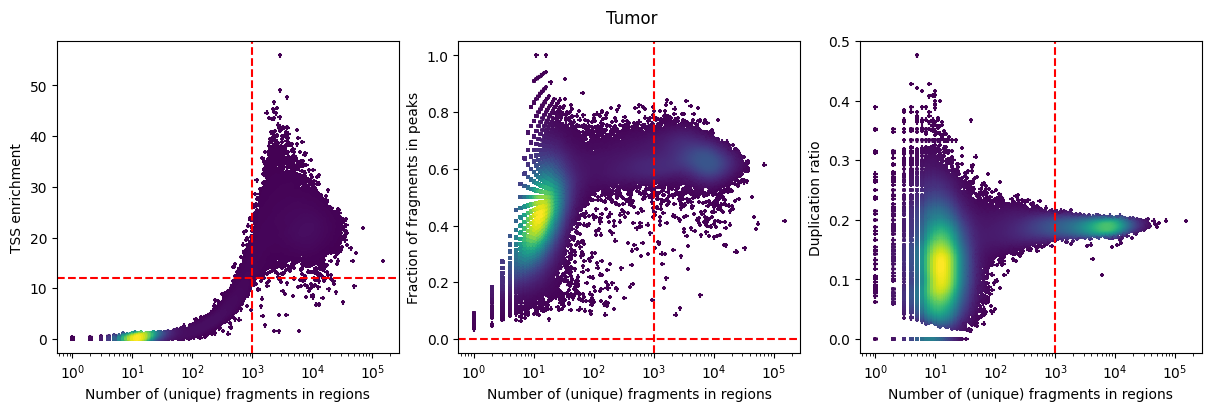

In [54]:
for sample_id in fragments_dict:
    fig = plot_barcode_stats(
        sample_id = sample_id,
        pycistopic_qc_output_dir = qcdir,
        bc_passing_filters = sample_id_to_barcodes_passing_filters[sample_id],
        detailed_title = False,
        **sample_id_to_thresholds[sample_id]
    )

After filtering, we have between 6,044 and 10,170 cells per sample.

In [55]:
for sample, bcs in sample_id_to_barcodes_passing_filters.items():
    print(f"{sample}: {len(bcs)}")

Ptch1GNP: 6044
PNC: 10170
Tumor: 8787


# Creating a cisTopic object

We are now using the filtered cell barcodes from the QC step to create the cisTopic object from the fragment files. _pycisTopic_ creates a count matrix based on the consensus peaks. In addition, peaks are filtered based on a blacklist, which can be downloaded from:

[https://github.com/Boyle-Lab/Blacklist](https://github.com/Boyle-Lab/Blacklist)

In [57]:
from pycisTopic.cistopic_class import create_cistopic_object_from_fragments
import polars as pl

indir = "/storage/nhecker/embl/GSE240362/pycistopic_mm10"

path_to_regions = os.path.join(indir, "consensus_peak_calling/consensus_regions.bed")
path_to_blacklist= "/storage/nhecker/blacklist/mm10-blacklist.v2.bed"
qcdir = "/storage/nhecker/embl/GSE240362/pycistopic_mm10/qc"

cistopic_obj_list = []
for sample_id in fragments_dict:
    sample_metrics = pl.read_parquet(
        os.path.join(qcdir, f'{sample_id}.fragments_stats_per_cb.parquet')
    ).to_pandas().set_index("CB").loc[ sample_id_to_barcodes_passing_filters[sample_id] ]
    cistopic_obj = create_cistopic_object_from_fragments(
        path_to_fragments = fragments_dict[sample_id],
        path_to_regions = path_to_regions,
        path_to_blacklist = path_to_blacklist,
        metrics = sample_metrics,
        valid_bc = sample_id_to_barcodes_passing_filters[sample_id],
        n_cpu = 1,
        project = sample_id,
        split_pattern = '__'
    )
    cistopic_obj_list.append(cistopic_obj)


2026-02-16 21:18:30,967 cisTopic     INFO     Reading data for Ptch1GNP
2026-02-16 21:18:57,336 cisTopic     INFO     metrics provided!
2026-02-16 21:18:58,844 cisTopic     INFO     Counting fragments in regions
2026-02-16 21:19:15,084 cisTopic     INFO     Creating fragment matrix


/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cistopic_class.py:886: PerformanceWarning: The following operation may generate 2288415544 cells in the resulting pandas object.
  .unstack(level="Name", fill_value=0)


2026-02-16 21:19:38,709 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-02-16 21:19:46,516 cisTopic     INFO     Removing blacklisted regions
2026-02-16 21:19:47,174 cisTopic     INFO     Creating CistopicObject
2026-02-16 21:19:47,856 cisTopic     INFO     Done!
2026-02-16 21:19:48,420 cisTopic     INFO     Reading data for PNC
2026-02-16 21:20:25,808 cisTopic     INFO     metrics provided!
2026-02-16 21:20:27,928 cisTopic     INFO     Counting fragments in regions
2026-02-16 21:20:52,627 cisTopic     INFO     Creating fragment matrix


/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cistopic_class.py:886: PerformanceWarning: The following operation may generate 3850677270 cells in the resulting pandas object.
  .unstack(level="Name", fill_value=0)


2026-02-16 21:21:37,703 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-02-16 21:21:50,691 cisTopic     INFO     Removing blacklisted regions
2026-02-16 21:21:51,400 cisTopic     INFO     Creating CistopicObject
2026-02-16 21:21:52,277 cisTopic     INFO     Done!
2026-02-16 21:21:52,874 cisTopic     INFO     Reading data for Tumor
2026-02-16 21:22:34,465 cisTopic     INFO     metrics provided!
2026-02-16 21:22:36,657 cisTopic     INFO     Counting fragments in regions
2026-02-16 21:23:03,030 cisTopic     INFO     Creating fragment matrix


/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/pycisTopic/cistopic_class.py:886: PerformanceWarning: The following operation may generate 3328085037 cells in the resulting pandas object.
  .unstack(level="Name", fill_value=0)


2026-02-16 21:24:37,924 cisTopic     INFO     Converting fragment matrix to sparse matrix
2026-02-16 21:24:49,349 cisTopic     INFO     Removing blacklisted regions
2026-02-16 21:24:50,068 cisTopic     INFO     Creating CistopicObject
2026-02-16 21:24:50,917 cisTopic     INFO     Done!


This creates a list of cisTopic objects per sample.

In [58]:
for cistopic_obj in cistopic_obj_list:
    print(cistopic_obj)

CistopicObject from project Ptch1GNP with n_cells × n_regions = 6044 × 378626
CistopicObject from project PNC with n_cells × n_regions = 10170 × 378631
CistopicObject from project Tumor with n_cells × n_regions = 8787 × 378751


We are merging them into one object.

In [59]:
cistopic_obj = cistopic_obj_list[0]

cistopic_obj.merge(cistopic_obj_list[1:], split_pattern = '__')

2026-02-16 21:24:53,244 cisTopic     INFO     cisTopic object 1 merged
2026-02-16 21:24:56,268 cisTopic     INFO     cisTopic object 2 merged


In [60]:
import pickle
pickle.dump(
    cistopic_obj,
    open(os.path.join(outdir, "cistopic_obj.pkl"), "wb")
)

Next, we are adding the cell metadata from the RNA anndata object.

In [61]:
import scanpy as sc

path_rna = '/storage/nhecker/embl/GSE240362/scanpy/rna_medulloblastoma.h5ad'

adata_rna = sc.read(path_rna)
cell_data = adata_rna.obs.copy()
cell_data

/home/nikolai/.conda/envs/scenicplus/lib/python3.11/site-packages/anndata/__init__.py:51: FutureWarning: `anndata.read` is deprecated, use `anndata.read_h5ad` instead. `ad.read` will be removed in mid 2024.
  warnings.warn(


,sample,doublet_score,predicted_doublet,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,pct_counts_in_top_50_genes,pct_counts_in_top_100_genes,pct_counts_in_top_200_genes,...,n_genes,leiden_0.1,leiden_0.25,leiden_0.5,leiden_0.75,leiden_1.0,leiden_1.5,leiden_2.0,leiden_2.5,leiden_3.0
AAACAGCCAAAGGTAC-1__Ptch1GNP,Ptch1GNP,0.112527,False,2327,7.752765,4287.0,8.363576,19.594122,25.705622,34.219734,...,2327,2,2,3,3,3,1,5,8,10
AAACAGCCAATGCCCG-1__Ptch1GNP,Ptch1GNP,0.010193,False,1624,7.393263,3181.0,8.065266,24.740648,32.977051,43.791261,...,1624,2,2,4,5,6,7,10,13,14
AAACAGCCACCTCACC-1__Ptch1GNP,Ptch1GNP,0.017131,False,3436,8.142354,8641.0,9.064389,21.444277,28.457354,37.044324,...,3436,4,5,7,8,11,16,18,22,25
AAACAGCCACGAACAG-1__Ptch1GNP,Ptch1GNP,0.202797,False,4443,8.399310,11592.0,9.358157,19.142512,25.258799,32.962388,...,4443,2,3,5,6,8,11,13,15,18
AAACAGCCATAATCAC-1__Ptch1GNP,Ptch1GNP,0.051130,False,1868,7.533159,3699.0,8.216088,25.574480,32.197891,41.605839,...,1868,2,2,3,3,3,1,8,8,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
TTTGTTGGTAACCTAG-1__Tumor,Tumor,0.040000,False,1025,6.933423,1979.0,7.590852,33.956544,42.546741,53.764528,...,1025,1,1,0,0,10,13,11,9,12
TTTGTTGGTACTGATG-1__Tumor,Tumor,0.166870,False,1415,7.255591,2690.0,7.897668,31.040892,38.066914,47.546468,...,1415,1,1,0,0,4,5,9,7,3
TTTGTTGGTATTCGTC-1__Tumor,Tumor,0.074952,False,407,6.011267,1080.0,6.985642,65.925926,71.574074,80.833333,...,407,1,1,0,0,1,0,12,11,8
TTTGTTGGTATTGTGG-1__Tumor,Tumor,0.066121,False,843,6.738152,1492.0,7.308543,34.182306,43.230563,56.635389,...,843,1,1,0,0,4,0,9,9,3


In [62]:
cistopic_obj

In [63]:
cistopic_obj.add_cell_data(cell_data, split_pattern='__')

pickle.dump(
    cistopic_obj,
    open(os.path.join(outdir, "cistopic_obj.pkl"), "wb")
)

In [64]:
cistopic_obj.cell_data

,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,barcode_rank,total_fragments_count,log10_total_fragments_count,unique_fragments_count,log10_unique_fragments_count,...,n_genes,leiden_0.1,leiden_0.25,leiden_0.5,leiden_0.75,leiden_1.0,leiden_1.5,leiden_2.0,leiden_2.5,leiden_3.0
TGTCCTTCAGTTATCG-1__Ptch1GNP,15412,4.187859,13143,4.118695,Ptch1GNP,445,32199,4.507856,21912,4.340702,...,2409.0,2,2,3,3,3,1,5,10,10
TTTGGCTGTACTTCAC-1__Ptch1GNP,4238,3.627161,3974,3.599228,Ptch1GNP,3712,8074,3.907143,5522,3.742175,...,3373.0,2,2,3,3,3,1,5,10,11
CGCAATTAGTCAATCA-1__Ptch1GNP,4070,3.609594,3808,3.580697,Ptch1GNP,3701,8074,3.907143,5543,3.743823,...,3162.0,2,3,5,6,8,11,13,15,18
ACAGCCGGTATGGTGC-1__Ptch1GNP,8934,3.951046,8089,3.907895,Ptch1GNP,1433,18755,4.273140,12967,4.112873,...,1658.0,2,2,4,5,6,7,10,13,14
GTTGTGAGTGTTTGAG-1__Ptch1GNP,9872,3.994405,8980,3.953276,Ptch1GNP,1210,20917,4.320520,14304,4.155488,...,1335.0,2,2,3,3,3,1,8,8,21
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTGACATCACGCCAA-1__Tumor,1206,3.081347,1185,3.073718,Tumor,8429,2471,3.393048,1974,3.295567,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
TGTCATAAGGACCTCA-1__Tumor,1519,3.181558,1456,3.163161,Tumor,8404,2451,3.389520,1996,3.300378,...,284.0,0,0,2,1,2,3,0,26,9
AGACCCGGTTCCTGAT-1__Tumor,1347,3.129368,1318,3.119915,Tumor,8571,2264,3.355068,1843,3.265761,...,954.0,1,1,0,0,1,9,12,11,8
AACTTAGTCTCACTCA-1__Tumor,1332,3.124504,1303,3.114944,Tumor,8738,2030,3.307710,1691,3.228400,...,602.0,1,1,0,0,1,9,12,11,8


# Topic models (Mallet)

After creating the cisTopic object, we can identify characteristic sets of accessible reagion, i.e. peaks, using topic modelling. We are using _Mallet_ for topic modelling. _Mallet_ can be downloaded from here:

`https://github.com/mimno/Mallet/releases/download/v202108/Mallet-202108-bin.tar.gz`

In [65]:
!mkdir -p /storage/nhecker/temp/ray_spill/mallet/meduloblastoma

When running the _Mallet_ wrapper function `run_cgs_models_mallet` it is advisable to specify a larger range of number of topics; for less complex data sets between 2 and 150; for more complex data sets up to 300 topics or even more. You may have to add pycisTopic to your `PATH` variable. This step will run for half a day or days depending on the size of the dataset and the number of topics.

In [66]:
os.environ['PATH']

'/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin:/bin:/snap/bin'

In [ ]:
os.environ['MALLET_MEMORY'] = '200G'
os.environ['PATH'] = "/home/nikolai/.conda/envs/scenicplus/bin:/opt/anaconda3/condabin:/opt/anaconda3/bin:/usr/local/sbin:/usr/local/bin:/usr/sbin:/usr/bin:/sbin"

from pycisTopic.lda_models import run_cgs_models_mallet
# Configure path Mallet
mallet_path="/storage/nhecker/embl/GSE240362/pycistopic/Mallet-202108/bin/mallet"
# Run models
models=run_cgs_models_mallet(
    cistopic_obj,
    n_topics=[2, 5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 60, 70, 80, 90, 100, 125, 150],
    n_cpu=12,
    n_iter=500,
    random_state=555,
    alpha=50,
    alpha_by_topic=True,
    eta=0.1,
    eta_by_topic=False,
    tmp_path="/storage/nhecker/temp/ray_spill/mallet/meduloblastoma",
    save_path="/storage/nhecker/temp/ray_spill/mallet/meduloblastoma",
    mallet_path=mallet_path,
)


2026-02-16 21:25:06,805 cisTopic     INFO     Formatting input to corpus
2026-02-16 21:25:07,589 cisTopic     INFO     Running model with 2 topics
2026-02-16 21:25:07,590 LDAMalletWrapper INFO     Serializing temporary corpus to /storage/nhecker/temp/ray_spill/mallet/meduloblastoma/corpus.txt
2026-02-16 21:25:41,039 LDAMalletWrapper INFO     Converting temporary corpus to MALLET format with: /storage/nhecker/embl/GSE240362/pycistopic/Mallet-202108/bin/mallet import-file --preserve-case --keep-sequence --token-regex \S+ --input /storage/nhecker/temp/ray_spill/mallet/meduloblastoma/corpus.txt --output /storage/nhecker/temp/ray_spill/mallet/meduloblastoma/corpus.mallet
2026-02-16 21:26:32,188 LDAMalletWrapper INFO     Training MALLET LDA with: /storage/nhecker/embl/GSE240362/pycistopic/Mallet-202108/bin/mallet train-topics --input /storage/nhecker/temp/ray_spill/mallet/meduloblastoma/corpus.mallet --num-topics 2 --alpha 50 --beta 0.1 --optimize-interval 0 --num-threads 12 --output-state /

In [69]:
pickle.dump(
    models,
    open(os.path.join(outdir, "models.pkl"), "wb")
)

We select the number of topics based on the metrics given by _pycisTopic_. The number of topics usually does not have a huge impact for downstrean analysis in SCENIC+ but should be selected in a dataset specific mannner to get the most out of the topics.

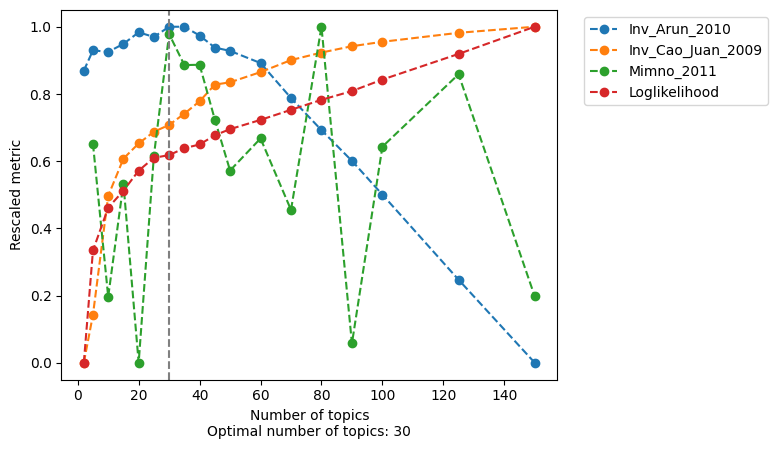

In [72]:
from pycisTopic.lda_models import evaluate_models
model = evaluate_models(
    models,
    select_model = 30,
    return_model = True
)

In [73]:
cistopic_obj.add_LDA_model(model)

In [74]:
outdir

'/storage/nhecker/embl/GSE240362/pycistopic_mm10'

In [75]:
pickle.dump(
    cistopic_obj,
    open(os.path.join(outdir, "cistopic_obj.pkl"), "wb")
)

In [76]:
os.path.join(outdir, "cistopic_obj.pkl")

'/storage/nhecker/embl/GSE240362/pycistopic_mm10/cistopic_obj.pkl'

# Clustering

Using the topics, we can cluster our data. Similarly to clustering gene expression data, this involved computing a nearest neighbour graph and using Leiden clustering.

In [1]:
import pickle as pkl

path_cistopic = "/storage/nhecker/embl/GSE240362/pycistopic_mm10/cistopic_obj.pkl"

with open(path_cistopic, 'rb') as file:
    cistopic_obj = pkl.load(file)

/opt/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-02-17 16:36:00,670	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [2]:
from pycisTopic.clust_vis import (
    find_clusters,
    run_umap,
    run_tsne,
    plot_metadata,
    plot_topic,
    cell_topic_heatmap
)

In [3]:
find_clusters(
    cistopic_obj,
    target  = 'cell',
    k = 10,
    res = [0.1, 0.25, 0.5, 1, 1.5, 2, 3],
    prefix = 'pycisTopic_',
    scale = True,
    split_pattern = '__'
)

2026-02-17 16:36:06,240 cisTopic     INFO     Finding neighbours
Columns ['pycisTopic_leiden_10_0.1'] will be overwritten
Columns ['pycisTopic_leiden_10_0.25'] will be overwritten
Columns ['pycisTopic_leiden_10_0.5'] will be overwritten
Columns ['pycisTopic_leiden_10_1'] will be overwritten
Columns ['pycisTopic_leiden_10_1.5'] will be overwritten
Columns ['pycisTopic_leiden_10_2'] will be overwritten
Columns ['pycisTopic_leiden_10_3'] will be overwritten


For the version of _pycisTopic_ that we are using here, we have to create an empty `cell` dictionary before we can computed and add a UMAP to the object.

In [4]:
cistopic_obj.projections['cell'] = {}

In [5]:
run_umap(
    cistopic_obj,
    target  = 'cell', scale=True)


2026-02-17 16:36:23,140 cisTopic     INFO     Running UMAP


/opt/venv/lib/python3.11/site-packages/umap/umap_.py:1943: UserWarning: n_jobs value -1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(f"n_jobs value {self.n_jobs} overridden to 1 by setting random_state. Use no seed for parallelism.")


In [6]:
run_tsne(
    cistopic_obj,
    target  = 'cell', scale=True)

2026-02-17 16:36:51,923 cisTopic     INFO     Running TSNE


In [7]:
cistopic_obj.cell_data

,log10_total_fragments_count,sample,log10_total_fragments_in_peaks_count,pycisTopic_leiden_10_0.5,nucleosome_signal,pct_counts_in_top_50_genes,pycisTopic_leiden_10_2,log1p_n_genes_by_counts,total_fragments_in_peaks_count,pct_counts_in_top_100_genes,...,pct_counts_ribo,fraction_of_fragments_in_peaks,leiden_1.0,cisTopic_nr_acc,log1p_total_counts_hb,leiden_0.25,leiden_3.0,log10_unique_fragments_count,barcode,pycisTopic_leiden_10_3
TGTCCTTCAGTTATCG-1__Ptch1GNP,4.507856,Ptch1GNP,4.341870,3,0.706585,21.888505,13,7.787382,21971,27.917027,...,0.0,0.683324,3,13143,0.0,2,10,4.340702,TGTCCTTCAGTTATCG-1,15
TTTGGCTGTACTTCAC-1__Ptch1GNP,3.907143,Ptch1GNP,3.778151,3,0.623880,18.885521,10,8.123854,5999,25.052460,...,0.0,0.742304,3,3974,0.0,2,11,3.742175,TTTGGCTGTACTTCAC-1,7
CGCAATTAGTCAATCA-1__Ptch1GNP,3.907143,Ptch1GNP,3.755646,3,0.685857,19.708940,2,8.059276,5696,26.139986,...,0.0,0.711528,8,3808,0.0,3,18,3.743823,CGCAATTAGTCAATCA-1,16
ACAGCCGGTATGGTGC-1__Ptch1GNP,4.273140,Ptch1GNP,4.098644,4,0.784485,22.556873,14,7.413970,12549,31.336110,...,0.0,0.669392,6,8089,0.0,2,14,4.112873,ACAGCCGGTATGGTGC-1,19
GTTGTGAGTGTTTGAG-1__Ptch1GNP,4.320520,Ptch1GNP,4.144419,3,0.828966,22.002821,13,7.197435,13944,29.995299,...,0.0,0.670652,3,8980,0.0,2,21,4.155488,GTTGTGAGTGTTTGAG-1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTGACATCACGCCAA-1__Tumor,3.393048,NaN,3.166134,0,0.801802,NaN,3,NaN,1465,NaN,...,NaN,0.591185,NaN,1185,NaN,NaN,NaN,3.295567,CGTGACATCACGCCAA-1,18
TGTCATAAGGACCTCA-1__Tumor,3.389520,Tumor,3.260787,2,0.611210,59.830508,15,5.652489,1822,68.813559,...,0.0,0.739479,2,1456,0.0,0,9,3.300378,TGTCATAAGGACCTCA-1,17
AGACCCGGTTCCTGAT-1__Tumor,3.355068,Tumor,3.205475,0,0.665005,26.657736,3,6.861711,1604,34.896182,...,0.0,0.708627,1,1318,0.0,1,8,3.265761,AGACCCGGTTCCTGAT-1,3
AACTTAGTCTCACTCA-1__Tumor,3.307710,Tumor,3.190051,0,0.622780,51.112943,5,6.401917,1548,58.615004,...,0.0,0.761679,1,1303,0.0,1,8,3.228400,AACTTAGTCTCACTCA-1,8


In [11]:
cistopic_obj.cell_data['sample'] = [ bc.split('__')[1] for bc in cistopic_obj.cell_data.index]
cistopic_obj.cell_data

,log10_total_fragments_count,sample,log10_total_fragments_in_peaks_count,pycisTopic_leiden_10_0.5,nucleosome_signal,pct_counts_in_top_50_genes,pycisTopic_leiden_10_2,log1p_n_genes_by_counts,total_fragments_in_peaks_count,pct_counts_in_top_100_genes,...,pct_counts_ribo,fraction_of_fragments_in_peaks,leiden_1.0,cisTopic_nr_acc,log1p_total_counts_hb,leiden_0.25,leiden_3.0,log10_unique_fragments_count,barcode,pycisTopic_leiden_10_3
TGTCCTTCAGTTATCG-1__Ptch1GNP,4.507856,Ptch1GNP,4.341870,3,0.706585,21.888505,13,7.787382,21971,27.917027,...,0.0,0.683324,3,13143,0.0,2,10,4.340702,TGTCCTTCAGTTATCG-1,15
TTTGGCTGTACTTCAC-1__Ptch1GNP,3.907143,Ptch1GNP,3.778151,3,0.623880,18.885521,10,8.123854,5999,25.052460,...,0.0,0.742304,3,3974,0.0,2,11,3.742175,TTTGGCTGTACTTCAC-1,7
CGCAATTAGTCAATCA-1__Ptch1GNP,3.907143,Ptch1GNP,3.755646,3,0.685857,19.708940,2,8.059276,5696,26.139986,...,0.0,0.711528,8,3808,0.0,3,18,3.743823,CGCAATTAGTCAATCA-1,16
ACAGCCGGTATGGTGC-1__Ptch1GNP,4.273140,Ptch1GNP,4.098644,4,0.784485,22.556873,14,7.413970,12549,31.336110,...,0.0,0.669392,6,8089,0.0,2,14,4.112873,ACAGCCGGTATGGTGC-1,19
GTTGTGAGTGTTTGAG-1__Ptch1GNP,4.320520,Ptch1GNP,4.144419,3,0.828966,22.002821,13,7.197435,13944,29.995299,...,0.0,0.670652,3,8980,0.0,2,21,4.155488,GTTGTGAGTGTTTGAG-1,15
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CGTGACATCACGCCAA-1__Tumor,3.393048,Tumor,3.166134,0,0.801802,NaN,3,NaN,1465,NaN,...,NaN,0.591185,NaN,1185,NaN,NaN,NaN,3.295567,CGTGACATCACGCCAA-1,18
TGTCATAAGGACCTCA-1__Tumor,3.389520,Tumor,3.260787,2,0.611210,59.830508,15,5.652489,1822,68.813559,...,0.0,0.739479,2,1456,0.0,0,9,3.300378,TGTCATAAGGACCTCA-1,17
AGACCCGGTTCCTGAT-1__Tumor,3.355068,Tumor,3.205475,0,0.665005,26.657736,3,6.861711,1604,34.896182,...,0.0,0.708627,1,1318,0.0,1,8,3.265761,AGACCCGGTTCCTGAT-1,3
AACTTAGTCTCACTCA-1__Tumor,3.307710,Tumor,3.190051,0,0.622780,51.112943,5,6.401917,1548,58.615004,...,0.0,0.761679,1,1303,0.0,1,8,3.228400,AACTTAGTCTCACTCA-1,8


To avoid issues with numeric values for the cluster names, we are converting them to strings.

In [8]:
cistopic_obj.cell_data['leiden_0.5'] = [str(clus) for clus in cistopic_obj.cell_data['leiden_0.5'] ]

The cells cluster quite well into sample specific clusters that are very similar to the gene expression based clusters `leiden_0.5`.

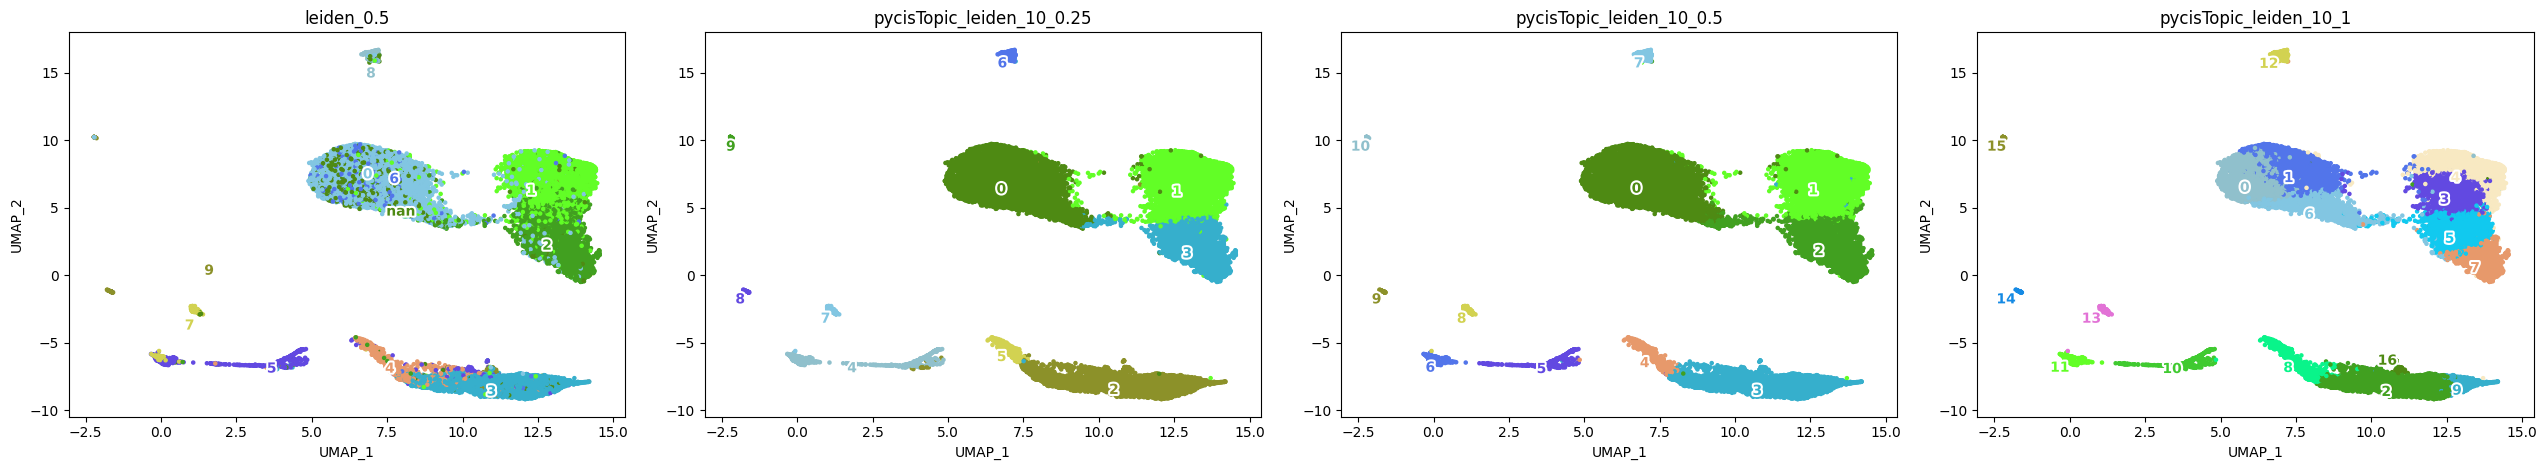

In [9]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['leiden_0.5', 'pycisTopic_leiden_10_0.25', 'pycisTopic_leiden_10_0.5', 'pycisTopic_leiden_10_1'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

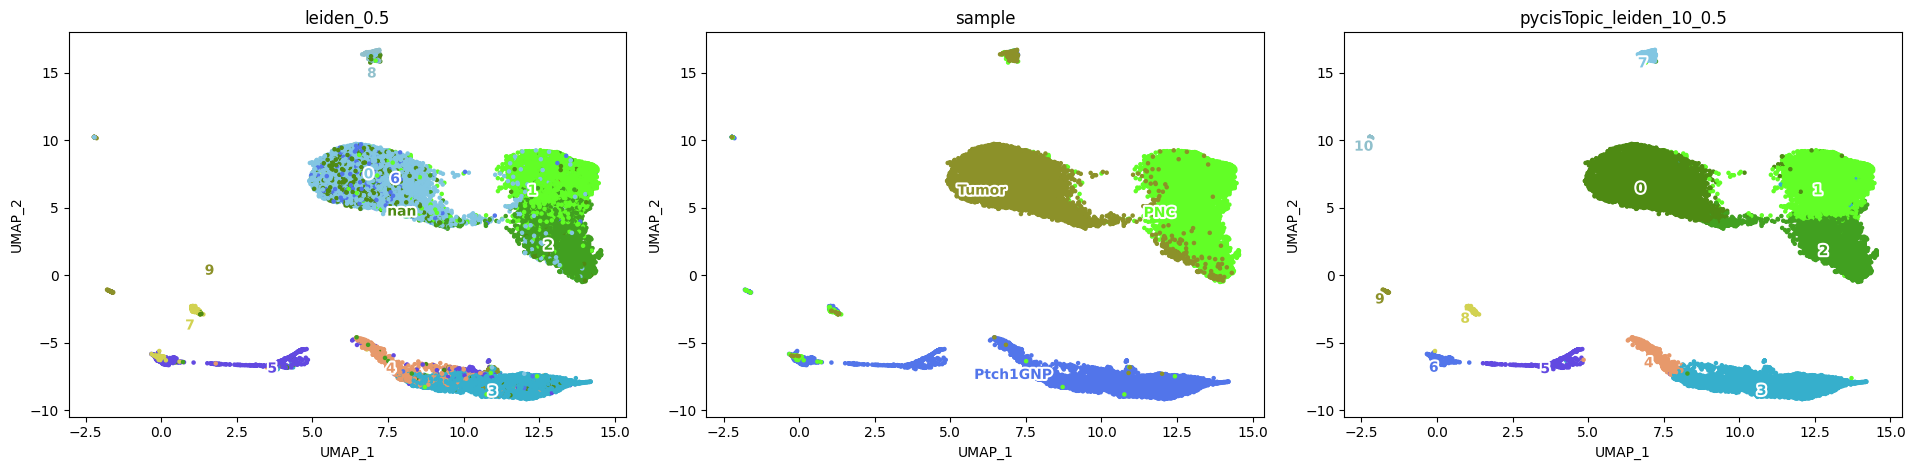

In [12]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['leiden_0.5', 'sample', 'pycisTopic_leiden_10_0.5'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

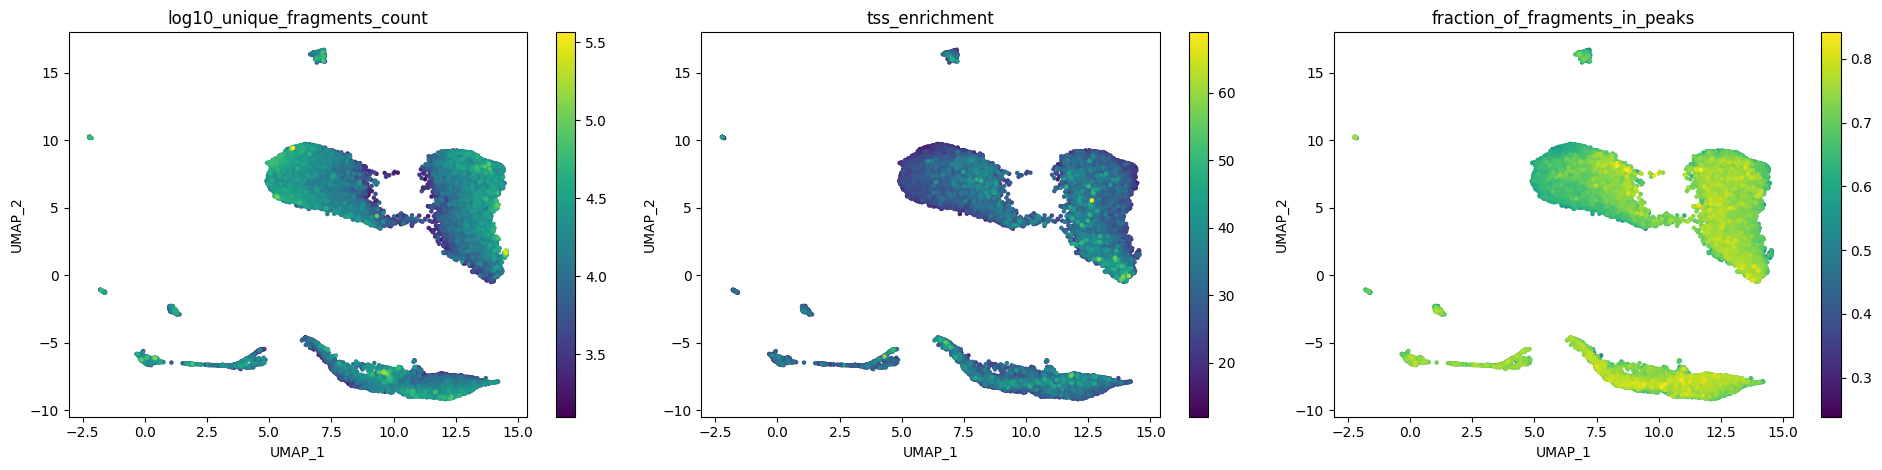

In [13]:
plot_metadata(
    cistopic_obj,
    reduction_name='UMAP',
    variables=['log10_unique_fragments_count', 'tss_enrichment', 'fraction_of_fragments_in_peaks'],
    target='cell', num_columns=4,
    text_size=10,
    dot_size=5)

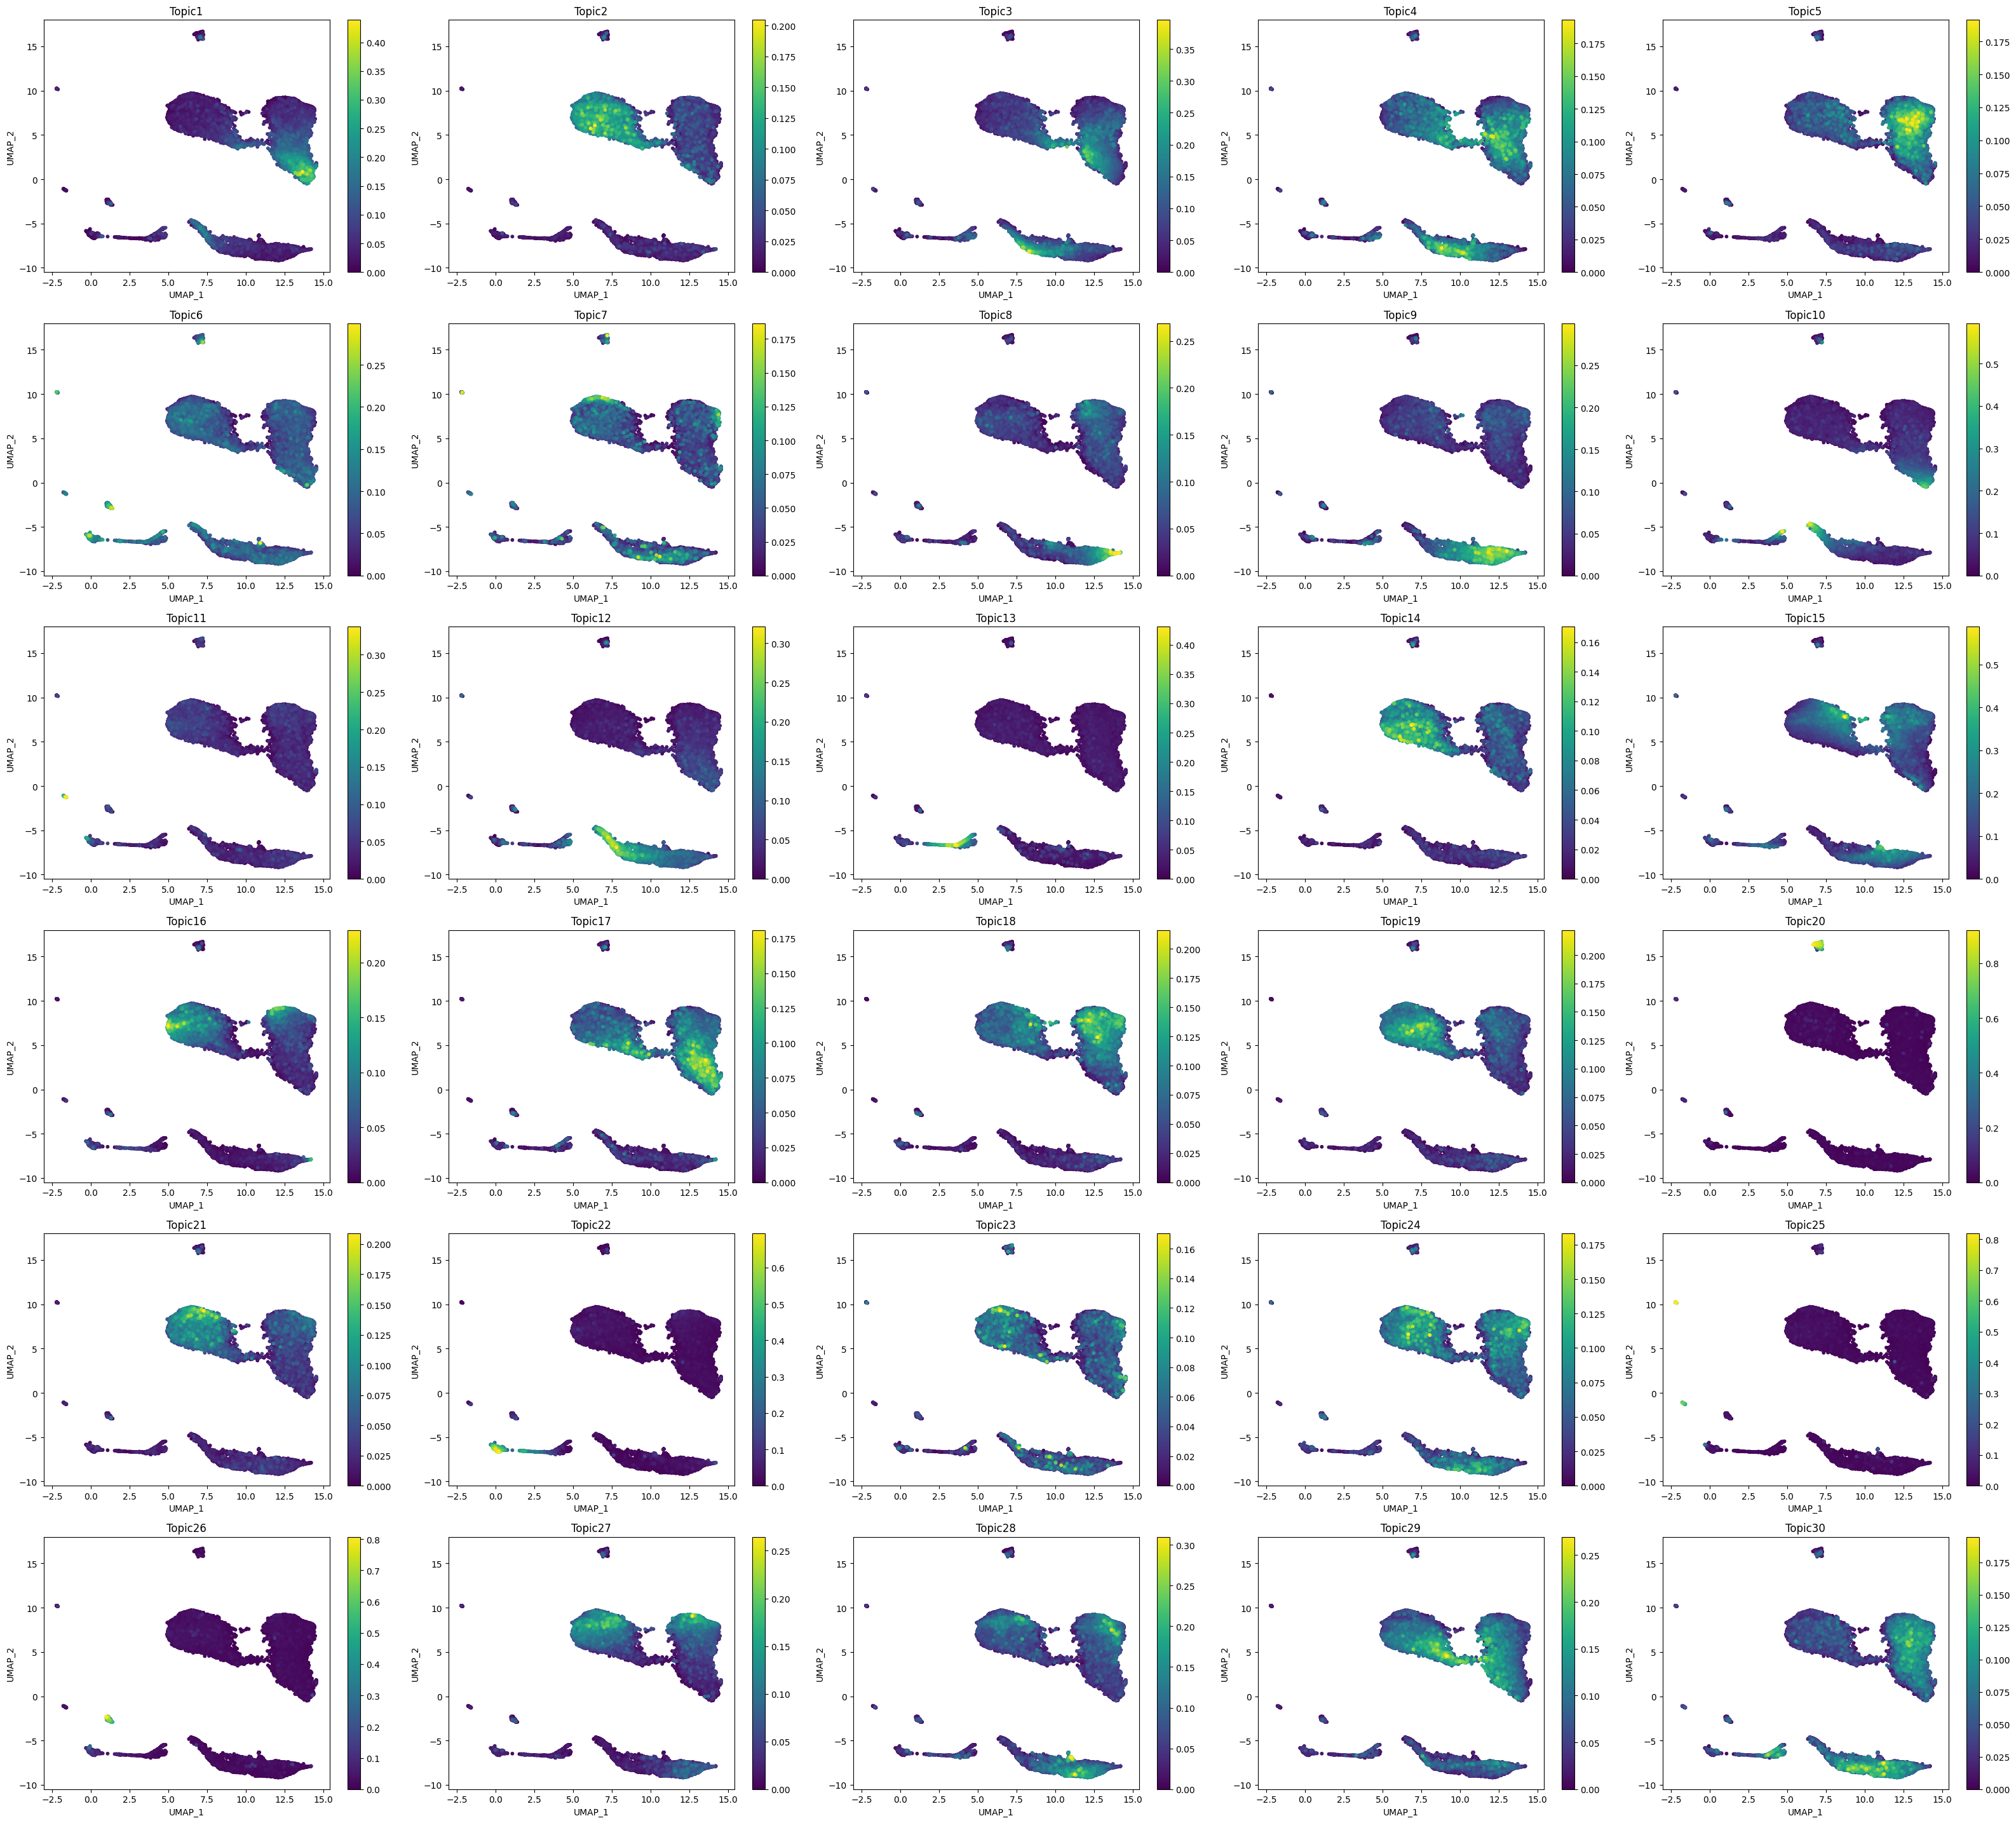

In [14]:
plot_topic(
    cistopic_obj,
    reduction_name = 'UMAP',
    target = 'cell',
    num_columns=5
)

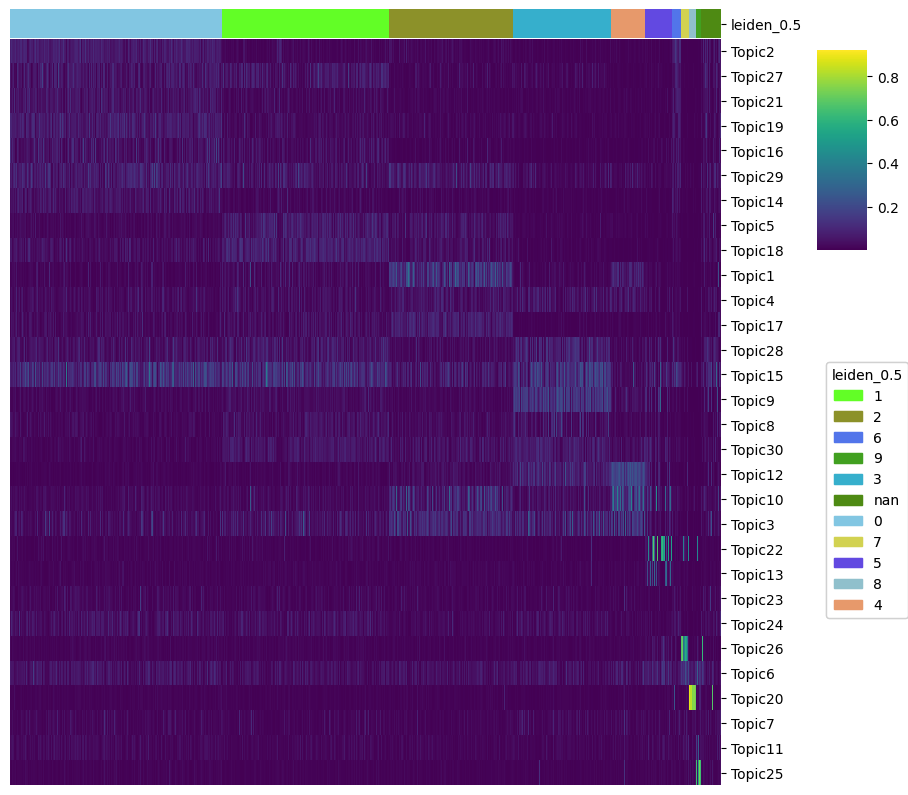

In [15]:
cell_topic_heatmap(
    cistopic_obj,
    variables = ['leiden_0.5'],
    scale = False,
    legend_loc_x = 1.0,
    legend_loc_y = -1.2,
    legend_dist_y = -1,
    figsize = (10, 10)
)

To limit the regions per topic to the most informative ones, we are using Otsu thresholding for binarizing the topics.

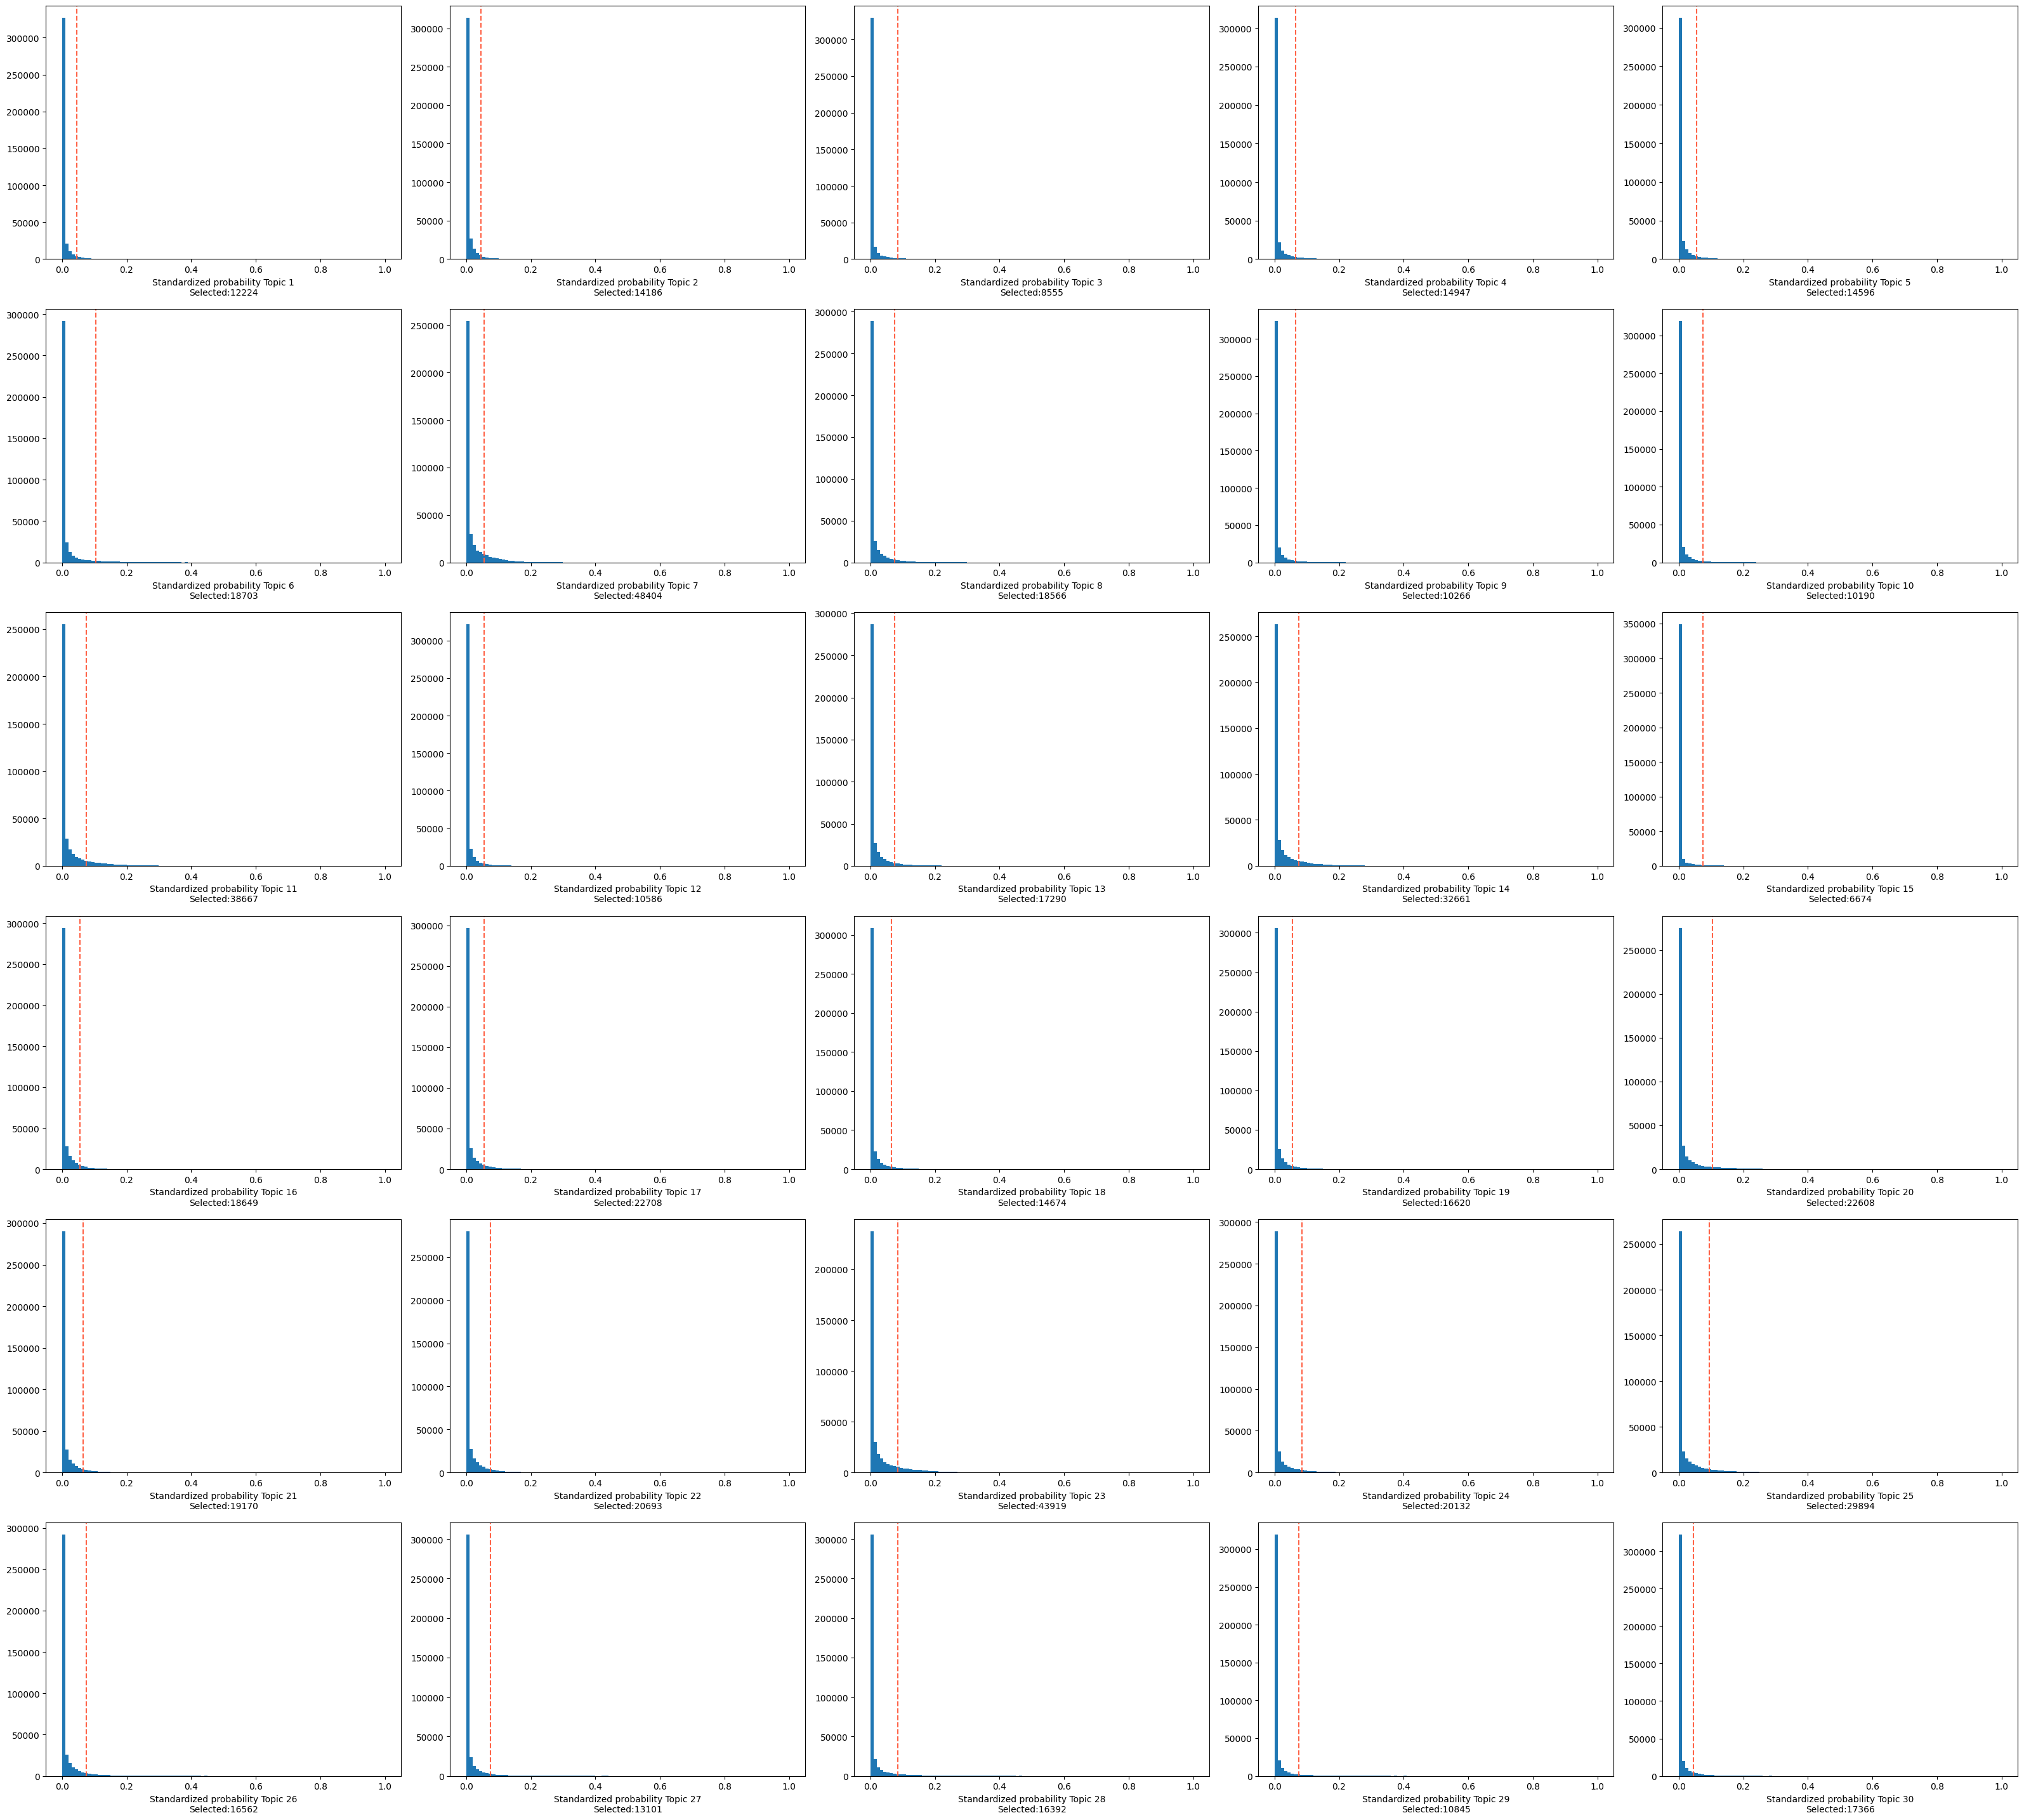

In [16]:
from pycisTopic.topic_binarization import binarize_topics

region_bin_topics_otsu = binarize_topics(
    cistopic_obj, method='otsu',
    plot=True, num_columns=5
)

We can also computed metrics per topic to assess how informative they are.

In [17]:
from pycisTopic.topic_qc import compute_topic_metrics, plot_topic_qc, topic_annotation
import matplotlib.pyplot as plt
from pycisTopic.utils import fig2img


topic_qc_metrics = compute_topic_metrics(cistopic_obj)

In [18]:
fig_dict={}
fig_dict['CoherenceVSAssignments']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Log10_Assignments', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSRegions_in_bin']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Regions_in_binarized_topic', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSMarginal_dist']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Marginal_topic_dist', var_color='Gini_index', plot=False, return_fig=True)
fig_dict['CoherenceVSGini_index']=plot_topic_qc(topic_qc_metrics, var_x='Coherence', var_y='Gini_index', var_color='Gini_index', plot=False, return_fig=True)

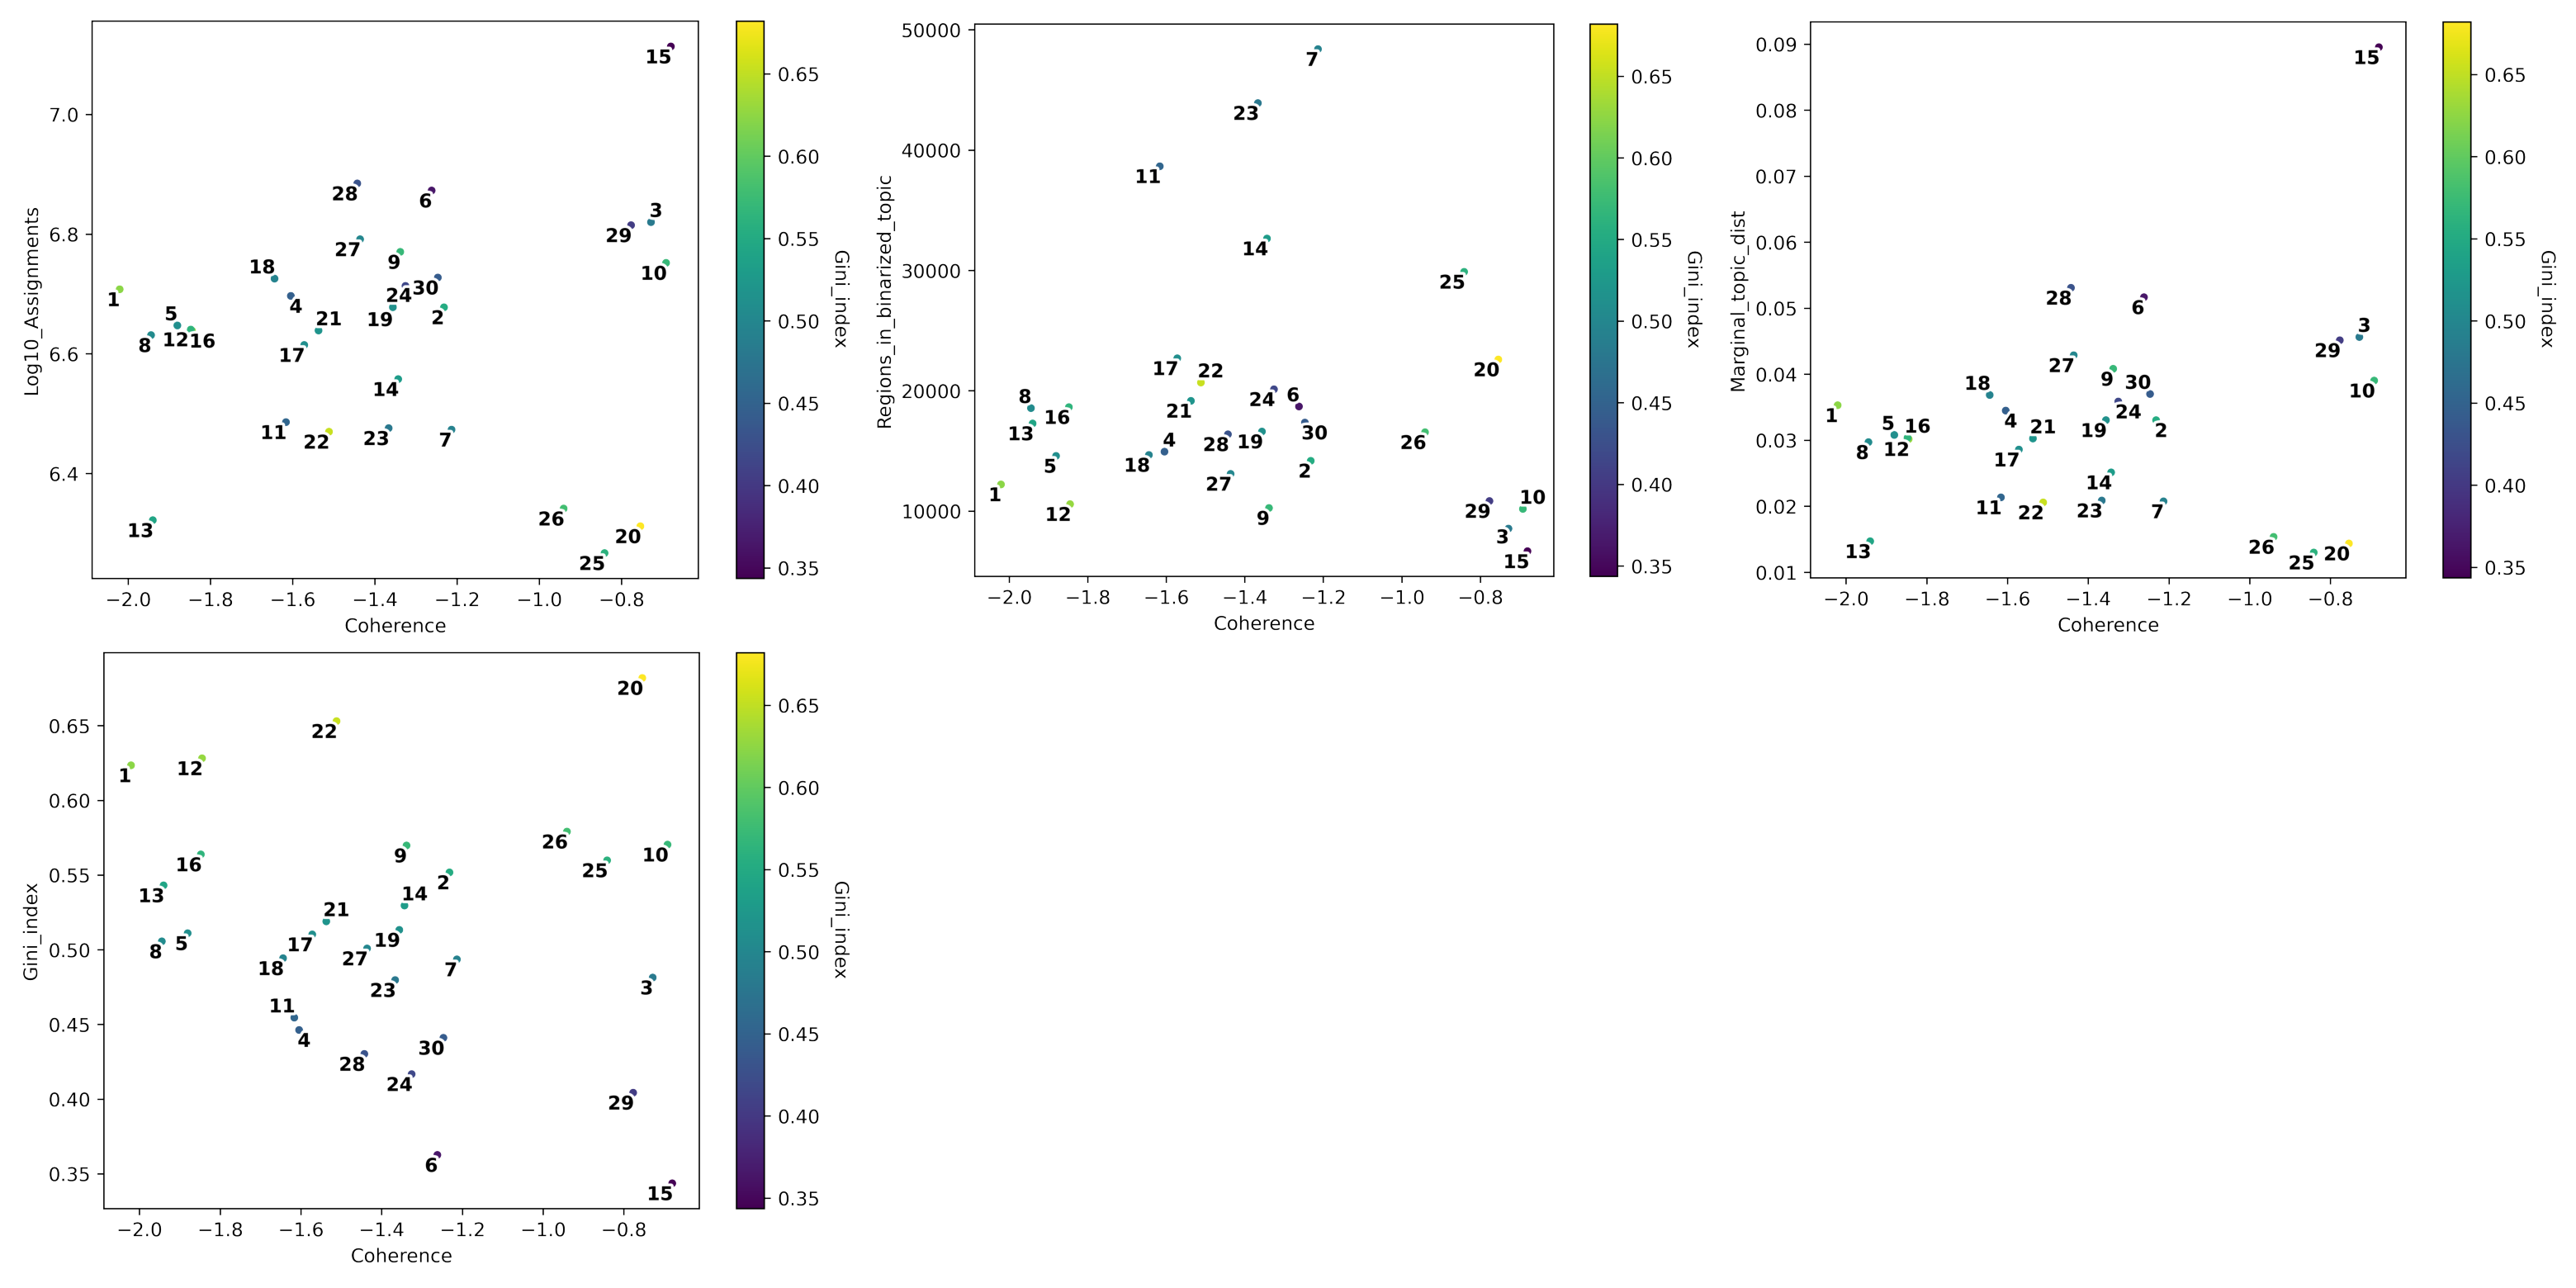

In [19]:
# Plot topic stats in one figure
fig=plt.figure(figsize=(40, 43))
i = 1
for fig_ in fig_dict.keys():
    plt.subplot(2, 3, i)
    img = fig2img(fig_dict[fig_]) #To convert figures to png to plot together, see .utils.py. This converts the figure to png.
    plt.imshow(img)
    plt.axis('off')
    i += 1
plt.subplots_adjust(wspace=0, hspace=-0.70)
plt.show()

In [20]:
import os
import pickle as pkl

outdir = "/storage/nhecker/embl/GSE240362/pycistopic_mm10"

pkl.dump(
    cistopic_obj,
    open(os.path.join(outdir, "cistopic_obj.pkl"), "wb")
)

# Differentially accessible regions (DARs)

SCENIC+ uses regions sets, that is DARs and topic regions, as input for inferring eRegulons. Here, we create the region sets and save them as BED files.

In [21]:
from pycisTopic.diff_features import (
    impute_accessibility,
    normalize_scores,
    find_highly_variable_features,
    find_diff_features
)
import numpy as np

imputed_acc_obj = impute_accessibility(
    cistopic_obj,
    selected_cells=None,
    selected_regions=None,
    scale_factor=10**6
)

2026-02-17 16:44:29,842 cisTopic     INFO     Imputing region accessibility
2026-02-17 16:44:29,843 cisTopic     INFO     Impute region accessibility for regions 0-20000
2026-02-17 16:44:30,835 cisTopic     INFO     Impute region accessibility for regions 20000-40000
2026-02-17 16:44:31,844 cisTopic     INFO     Impute region accessibility for regions 40000-60000
2026-02-17 16:44:32,860 cisTopic     INFO     Impute region accessibility for regions 60000-80000
2026-02-17 16:44:33,867 cisTopic     INFO     Impute region accessibility for regions 80000-100000
2026-02-17 16:44:34,873 cisTopic     INFO     Impute region accessibility for regions 100000-120000
2026-02-17 16:44:35,881 cisTopic     INFO     Impute region accessibility for regions 120000-140000
2026-02-17 16:44:36,884 cisTopic     INFO     Impute region accessibility for regions 140000-160000
2026-02-17 16:44:37,897 cisTopic     INFO     Impute region accessibility for regions 160000-180000
2026-02-17 16:44:38,909 cisTopic     

In [22]:
normalized_imputed_acc_obj = normalize_scores(imputed_acc_obj, scale_factor=10**4)

2026-02-17 16:44:48,982 cisTopic     INFO     Normalizing imputed data
2026-02-17 16:45:17,118 cisTopic     INFO     Done!


2026-02-17 16:45:17,123 cisTopic     INFO     Calculating mean
2026-02-17 16:45:21,031 cisTopic     INFO     Calculating variance


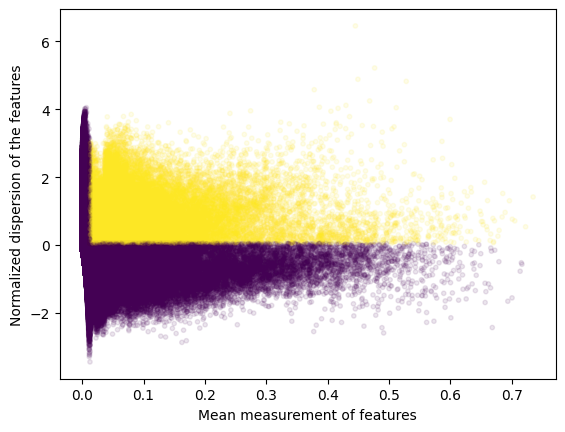

2026-02-17 16:47:49,458 cisTopic     INFO     Done!


In [23]:
variable_regions = find_highly_variable_features(
    normalized_imputed_acc_obj,
    min_disp = 0.05,
    min_mean = 0.0125,
    max_mean = 3,
    max_disp = np.inf,
    n_bins=20,
    n_top_features=None,
    plot=True
)

In [24]:
len(variable_regions)

36351

In [25]:
markers_dict_rnaclusters = find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable='leiden_0.5',
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    _temp_dir='/storage/nhecker/temp/ray_spill',
    split_pattern = '__'
)

2026-02-17 16:47:54,479	INFO worker.py:1724 -- Started a local Ray instance.


2026-02-17 16:47:54,809 cisTopic     INFO     Subsetting data for 0 (7458 of 25001)
2026-02-17 16:47:59,167 cisTopic     INFO     Computing p-value for 0
2026-02-17 16:48:11,183 cisTopic     INFO     Computing log2FC for 0
2026-02-17 16:48:14,380 cisTopic     INFO     0 done!
2026-02-17 16:48:14,701 cisTopic     INFO     Subsetting data for 1 (5860 of 25001)
2026-02-17 16:48:14,848 cisTopic     INFO     Computing p-value for 1
2026-02-17 16:48:25,859 cisTopic     INFO     Computing log2FC for 1
2026-02-17 16:48:25,900 cisTopic     INFO     1 done!
2026-02-17 16:48:26,232 cisTopic     INFO     Subsetting data for 2 (4370 of 25001)
2026-02-17 16:48:26,404 cisTopic     INFO     Computing p-value for 2
2026-02-17 16:48:37,686 cisTopic     INFO     Computing log2FC for 2
2026-02-17 16:48:37,721 cisTopic     INFO     2 done!
2026-02-17 16:48:38,041 cisTopic     INFO     Subsetting data for 3 (3439 of 25001)
2026-02-17 16:48:38,187 cisTopic     INFO     Computing p-value for 3
2026-02-17 16:4

In [26]:
print("Number of DARs found:")
print("---------------------")
for x in markers_dict_rnaclusters:
    print(f"  {x}: {len(markers_dict_rnaclusters[x])}")

Number of DARs found:
---------------------
  0: 6129
  1: 2494
  2: 8303
  3: 6617
  4: 9103
  5: 6847
  6: 1586
  7: 5621
  8: 3428
  9: 3574
  nan: 1214


In [27]:
clustering_name = 'pycisTopic_leiden_10_0.5'

markers_dict_pycistopic= find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable=clustering_name,
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    _temp_dir='/storage/nhecker/temp/ray_spill',
    split_pattern = '__'
)

2026-02-17 16:50:18,968	INFO worker.py:1724 -- Started a local Ray instance.


2026-02-17 16:50:19,267 cisTopic     INFO     Subsetting data for 0 (8413 of 25001)
2026-02-17 16:50:19,440 cisTopic     INFO     Computing p-value for 0
2026-02-17 16:50:31,446 cisTopic     INFO     Computing log2FC for 0
2026-02-17 16:50:31,488 cisTopic     INFO     0 done!
2026-02-17 16:50:31,806 cisTopic     INFO     Subsetting data for 1 (5997 of 25001)
2026-02-17 16:50:31,948 cisTopic     INFO     Computing p-value for 1
2026-02-17 16:50:43,047 cisTopic     INFO     Computing log2FC for 1
2026-02-17 16:50:43,088 cisTopic     INFO     1 done!
2026-02-17 16:50:43,417 cisTopic     INFO     Subsetting data for 10 (66 of 25001)
2026-02-17 16:50:43,574 cisTopic     INFO     Computing p-value for 10
2026-02-17 16:50:55,200 cisTopic     INFO     Computing log2FC for 10
2026-02-17 16:50:55,227 cisTopic     INFO     10 done!
2026-02-17 16:50:55,548 cisTopic     INFO     Subsetting data for 2 (4175 of 25001)
2026-02-17 16:50:55,689 cisTopic     INFO     Computing p-value for 2
2026-02-17 16

In [28]:
print("Number of DARs found:")
print("---------------------")
for x in markers_dict_pycistopic:
    print(f"  {x}: {len(markers_dict_pycistopic[x])}")

Number of DARs found:
---------------------
  0: 6918
  1: 2899
  10: 4184
  2: 8617
  3: 7016
  4: 9538
  5: 6598
  6: 7442
  7: 3381
  8: 5205
  9: 4285


In [29]:
clustering_name = 'sample'

markers_dict_sample= find_diff_features(
    cistopic_obj,
    imputed_acc_obj,
    variable=clustering_name,
    var_features=variable_regions,
    contrasts=None,
    adjpval_thr=0.05,
    log2fc_thr=np.log2(1.5),
    n_cpu=5,
    _temp_dir='/storage/nhecker/temp/ray_spill',
    split_pattern = '__'
)

2026-02-17 16:52:36,156	INFO worker.py:1724 -- Started a local Ray instance.


2026-02-17 16:52:36,473 cisTopic     INFO     Subsetting data for PNC (10170 of 25001)
2026-02-17 16:52:36,619 cisTopic     INFO     Computing p-value for PNC
2026-02-17 16:52:48,748 cisTopic     INFO     Computing log2FC for PNC
2026-02-17 16:52:48,790 cisTopic     INFO     PNC done!
2026-02-17 16:52:49,110 cisTopic     INFO     Subsetting data for Ptch1GNP (6044 of 25001)
2026-02-17 16:52:49,264 cisTopic     INFO     Computing p-value for Ptch1GNP
2026-02-17 16:53:00,195 cisTopic     INFO     Computing log2FC for Ptch1GNP
2026-02-17 16:53:00,224 cisTopic     INFO     Ptch1GNP done!
2026-02-17 16:53:00,546 cisTopic     INFO     Subsetting data for Tumor (8787 of 25001)
2026-02-17 16:53:00,687 cisTopic     INFO     Computing p-value for Tumor
2026-02-17 16:53:12,315 cisTopic     INFO     Computing log2FC for Tumor
2026-02-17 16:53:12,349 cisTopic     INFO     Tumor done!


In [30]:
print("Number of DARs found:")
print("---------------------")
for x in markers_dict_sample:
    print(f"  {x}: {len(markers_dict_sample[x])}")

Number of DARs found:
---------------------
  PNC: 5729
  Ptch1GNP: 7510
  Tumor: 6233


In [31]:
os.makedirs(os.path.join(outdir, "region_sets"), exist_ok = True)
os.makedirs(os.path.join(outdir, "region_sets", "Topics_otsu"), exist_ok = True)
os.makedirs(os.path.join(outdir, "region_sets", "DARs_leiden0_5_rna"), exist_ok = True)
os.makedirs(os.path.join(outdir, "region_sets", "DARs_leiden0_5_atac"), exist_ok = True)
os.makedirs(os.path.join(outdir, "region_sets", "DARs_sample"), exist_ok = True)

In [32]:
from pycisTopic.utils import region_names_to_coordinates

for topic in region_bin_topics_otsu:
    region_names_to_coordinates(
        region_bin_topics_otsu[topic].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outdir, "region_sets", "Topics_otsu", f"{topic}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [33]:
for cell_type in markers_dict_rnaclusters:
    region_names_to_coordinates(
        markers_dict_rnaclusters[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outdir, "region_sets", "DARs_leiden0_5_rna", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [34]:
for cell_type in markers_dict_pycistopic:
    region_names_to_coordinates(
        markers_dict_pycistopic[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outdir, "region_sets", "DARs_leiden0_5_atac", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

In [35]:
for cell_type in markers_dict_sample:
    region_names_to_coordinates(
        markers_dict_sample[cell_type].index
    ).sort_values(
        ["Chromosome", "Start", "End"]
    ).to_csv(
        os.path.join(outdir, "region_sets", "DARs_sample", f"{cell_type}.bed"),
        sep = "\t",
        header = False, index = False
    )

As a cleanup, remove the `nan.bed` file from gene expression cluster-based as they simply belong to different cells that were filtered out in the gene expression modality.

In [36]:
os.path.join(outdir, "region_sets", "DARs_leiden0_5_rna")

'/storage/nhecker/embl/GSE240362/pycistopic_mm10/region_sets/DARs_leiden0_5_rna'

In [37]:
! ls /storage/nhecker/embl/GSE240362/pycistopic_mm10/region_sets/DARs_leiden0_5_rna

0.bed  1.bed  2.bed  3.bed  4.bed  5.bed  6.bed  7.bed	8.bed  9.bed  nan.bed


In [38]:
! rm /storage/nhecker/embl/GSE240362/pycistopic_mm10/region_sets/DARs_leiden0_5_rna/nan.bed

In [39]:
! ls /storage/nhecker/embl/GSE240362/pycistopic_mm10/region_sets/DARs_leiden0_5_rna

0.bed  1.bed  2.bed  3.bed  4.bed  5.bed  6.bed  7.bed	8.bed  9.bed
